In [1]:
#Importamos las bibliotecas necesarias
import os
import numpy as np
import pandas as pd
from math import pi
import seaborn as sns
import No_Supervisados as ns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import dendrogram, ward, single, complete,average,linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.options.display.max_rows = 10

In [2]:
import No_Supervisados

In [3]:
# Opción a
path = "/home/dnunezf/Documents/AI_LABS/Lab_12-03-2026/movies_budget.csv"
df = pd.read_csv(path,delimiter=',',decimal=".", index_col=0)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 1 to 15
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   budget_musd      15 non-null     int64  
 1   box_office_musd  15 non-null     int64  
 2   runtime_min      15 non-null     int64  
 3   imdb_rating      15 non-null     float64
 4   metascore        15 non-null     int64  
 5   votes_thousands  15 non-null     int64  
 6   year             15 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 960.0 bytes


In [5]:
df.shape

(15, 7)

In [6]:
df.dtypes

budget_musd          int64
box_office_musd      int64
runtime_min          int64
imdb_rating        float64
metascore            int64
votes_thousands      int64
year                 int64
dtype: object

In [7]:
df.head()

,budget_musd,box_office_musd,runtime_min,imdb_rating,metascore,votes_thousands,year
movie_id,,,,,,,
1,160,829,136,8.5,84,1800,2014
2,200,1347,152,7.8,75,2100,2015
3,150,873,141,8.1,79,1650,2016
4,90,463,113,7.3,68,980,2012
5,120,657,130,7.6,72,1200,2013


In [8]:
df_numerico = df.select_dtypes(include = ["number"])

In [9]:
df_numerico.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 1 to 15
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   budget_musd      15 non-null     int64  
 1   box_office_musd  15 non-null     int64  
 2   runtime_min      15 non-null     int64  
 3   imdb_rating      15 non-null     float64
 4   metascore        15 non-null     int64  
 5   votes_thousands  15 non-null     int64  
 6   year             15 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 960.0 bytes


In [10]:
# distancia con métrica euclideana
dist = pdist(df_numerico, metric="euclidean")
dist

array([ 600.21870181,  156.8124995 ,  901.13619392,  625.59236728,
        328.24242566, 1261.02282295,  975.42710645,  311.52104263,
       1514.4256337 ,  459.8147888 ,  181.67897512, 1086.44740324,
        776.08312055,  738.41736843,  655.60208206, 1431.61979939,
       1137.10027702,  272.91969515, 1781.90931587,  430.95105291,
        744.83220258, 2031.40904054,  967.56137273,  543.75273792,
       1606.26912129,  213.56881795, 1251.74404732,  788.36643764,
        500.23519468,  389.82433223, 1145.85402212, 1061.83348977,
        154.89041287, 1398.66063075,  328.88168085,  119.86246285,
        969.79843267,  851.85870307,  615.60335444,  295.36771997,
       1175.61422669,  360.07660296, 1848.30164205,  688.06566547,
        613.44489565,  464.45899711,  890.66407248,  187.85909613,
       1635.56219386,  183.64642659,  883.68000996,  647.13792193,
       1555.83489163,  393.08280298,  899.20365324,  171.80806151,
        597.60702807,  470.92594959, 1342.12480791,  115.68076

In [11]:
# distancia con métrica ChebyShev
dist = pdist(df_numerico, metric="chebyshev")
dist

array([ 518.,  150.,  820.,  600.,  291., 1150.,  700.,  300., 1380.,
        450.,  151., 1000.,  591.,  700.,  474., 1120.,  900.,  227.,
       1450.,  400.,  600., 1680.,  750.,  400., 1300.,  200., 1000.,
        670.,  450.,  300., 1000.,  850.,  150., 1230.,  300.,  107.,
        850.,  650.,  550.,  220.,  970.,  330., 1520.,  520.,  560.,
        370.,  720.,  180., 1320.,  137.,  750.,  550., 1300.,  300.,
        780.,  150.,  500.,  400., 1100.,  100., 1300.,  550.,  450.,
       1530.,  600.,  250., 1150.,  350.,  850., 1850.,  850.,  230.,
        700., 1050.,  150., 1650.,  450., 1000., 2080., 1150.,  800.,
       1700.,  200., 1400., 1080.,  170.,  200.,  700.,  800.,  400.,
        930., 1280.,  380., 1880.,  680.,  350.,  550.,  950.,  250.,
        900.,  600.,  600., 1500.,  300., 1200.])

In [12]:
# Opción b
#Calculamos las agregaciones. Retorna los datos necesarios para dendograma.
ward_res = ward(df_numerico)         #Ward
average_res = average(df_numerico)   #Promedio
single_res  = single(df_numerico)     #Salto mínimo
complete_res = complete(df_numerico) #Salto Máximo

In [13]:
print(ward_res)

[[4.00000000e+00 1.40000000e+01 1.15680768e+02 2.00000000e+00]
 [2.00000000e+00 1.10000000e+01 1.19862463e+02 2.00000000e+00]
 [6.00000000e+00 1.20000000e+01 1.76742864e+02 2.00000000e+00]
 [0.00000000e+00 1.60000000e+01 1.83328312e+02 3.00000000e+00]
 [1.00000000e+00 1.30000000e+01 2.13568818e+02 2.00000000e+00]
 [8.00000000e+00 1.00000000e+01 2.26989075e+02 2.00000000e+00]
 [3.00000000e+00 1.50000000e+01 2.76015797e+02 3.00000000e+00]
 [7.00000000e+00 1.90000000e+01 3.74425783e+02 3.00000000e+00]
 [9.00000000e+00 1.70000000e+01 3.93958966e+02 3.00000000e+00]
 [5.00000000e+00 1.80000000e+01 3.98702897e+02 4.00000000e+00]
 [2.00000000e+01 2.40000000e+01 6.09326754e+02 6.00000000e+00]
 [2.10000000e+01 2.30000000e+01 9.30827453e+02 6.00000000e+00]
 [2.20000000e+01 2.50000000e+01 1.65005748e+03 9.00000000e+00]
 [2.60000000e+01 2.70000000e+01 3.22068977e+03 1.50000000e+01]]


In [14]:
print(average_res)

[[4.00000000e+00 1.40000000e+01 1.15680768e+02 2.00000000e+00]
 [2.00000000e+00 1.10000000e+01 1.19862463e+02 2.00000000e+00]
 [0.00000000e+00 1.60000000e+01 1.69245737e+02 3.00000000e+00]
 [6.00000000e+00 1.20000000e+01 1.76742864e+02 2.00000000e+00]
 [1.00000000e+00 1.30000000e+01 2.13568818e+02 2.00000000e+00]
 [8.00000000e+00 1.70000000e+01 2.26858323e+02 4.00000000e+00]
 [1.00000000e+01 1.50000000e+01 2.29603448e+02 3.00000000e+00]
 [3.00000000e+00 1.80000000e+01 2.73967850e+02 3.00000000e+00]
 [7.00000000e+00 1.90000000e+01 3.24309127e+02 3.00000000e+00]
 [5.00000000e+00 2.00000000e+01 3.75778242e+02 5.00000000e+00]
 [9.00000000e+00 2.20000000e+01 4.32018753e+02 4.00000000e+00]
 [2.10000000e+01 2.40000000e+01 5.81865253e+02 8.00000000e+00]
 [2.50000000e+01 2.60000000e+01 9.57725850e+02 1.20000000e+01]
 [2.30000000e+01 2.70000000e+01 1.28990633e+03 1.50000000e+01]]


In [15]:
print(single_res)

[[  4.          14.         115.68076763   2.        ]
 [  2.          11.         119.86246285   2.        ]
 [  8.          16.         154.89041287   3.        ]
 [  0.          17.         156.8124995    4.        ]
 [ 10.          15.         171.80806151   3.        ]
 [  6.          12.         176.74286407   2.        ]
 [  3.          19.         183.64642659   4.        ]
 [ 20.          21.         187.85909613   6.        ]
 [  1.          13.         213.56881795   2.        ]
 [  7.          23.         217.6672001    3.        ]
 [ 18.          22.         226.98907463  10.        ]
 [  9.          25.         253.42683362  11.        ]
 [  5.          24.         272.91969515   4.        ]
 [ 26.          27.         286.72293246  15.        ]]


In [16]:
print(complete_res)

[[4.00000000e+00 1.40000000e+01 1.15680768e+02 2.00000000e+00]
 [2.00000000e+00 1.10000000e+01 1.19862463e+02 2.00000000e+00]
 [6.00000000e+00 1.20000000e+01 1.76742864e+02 2.00000000e+00]
 [0.00000000e+00 1.60000000e+01 1.81678975e+02 3.00000000e+00]
 [1.00000000e+00 1.30000000e+01 2.13568818e+02 2.00000000e+00]
 [8.00000000e+00 1.00000000e+01 2.26989075e+02 2.00000000e+00]
 [3.00000000e+00 1.50000000e+01 2.95367720e+02 3.00000000e+00]
 [5.00000000e+00 1.80000000e+01 3.89824332e+02 4.00000000e+00]
 [9.00000000e+00 1.70000000e+01 4.29184529e+02 3.00000000e+00]
 [7.00000000e+00 1.90000000e+01 4.30951053e+02 3.00000000e+00]
 [2.00000000e+01 2.10000000e+01 6.88065665e+02 5.00000000e+00]
 [2.20000000e+01 2.40000000e+01 1.06183349e+03 7.00000000e+00]
 [2.30000000e+01 2.50000000e+01 1.28754804e+03 8.00000000e+00]
 [2.60000000e+01 2.70000000e+01 2.45387771e+03 1.50000000e+01]]


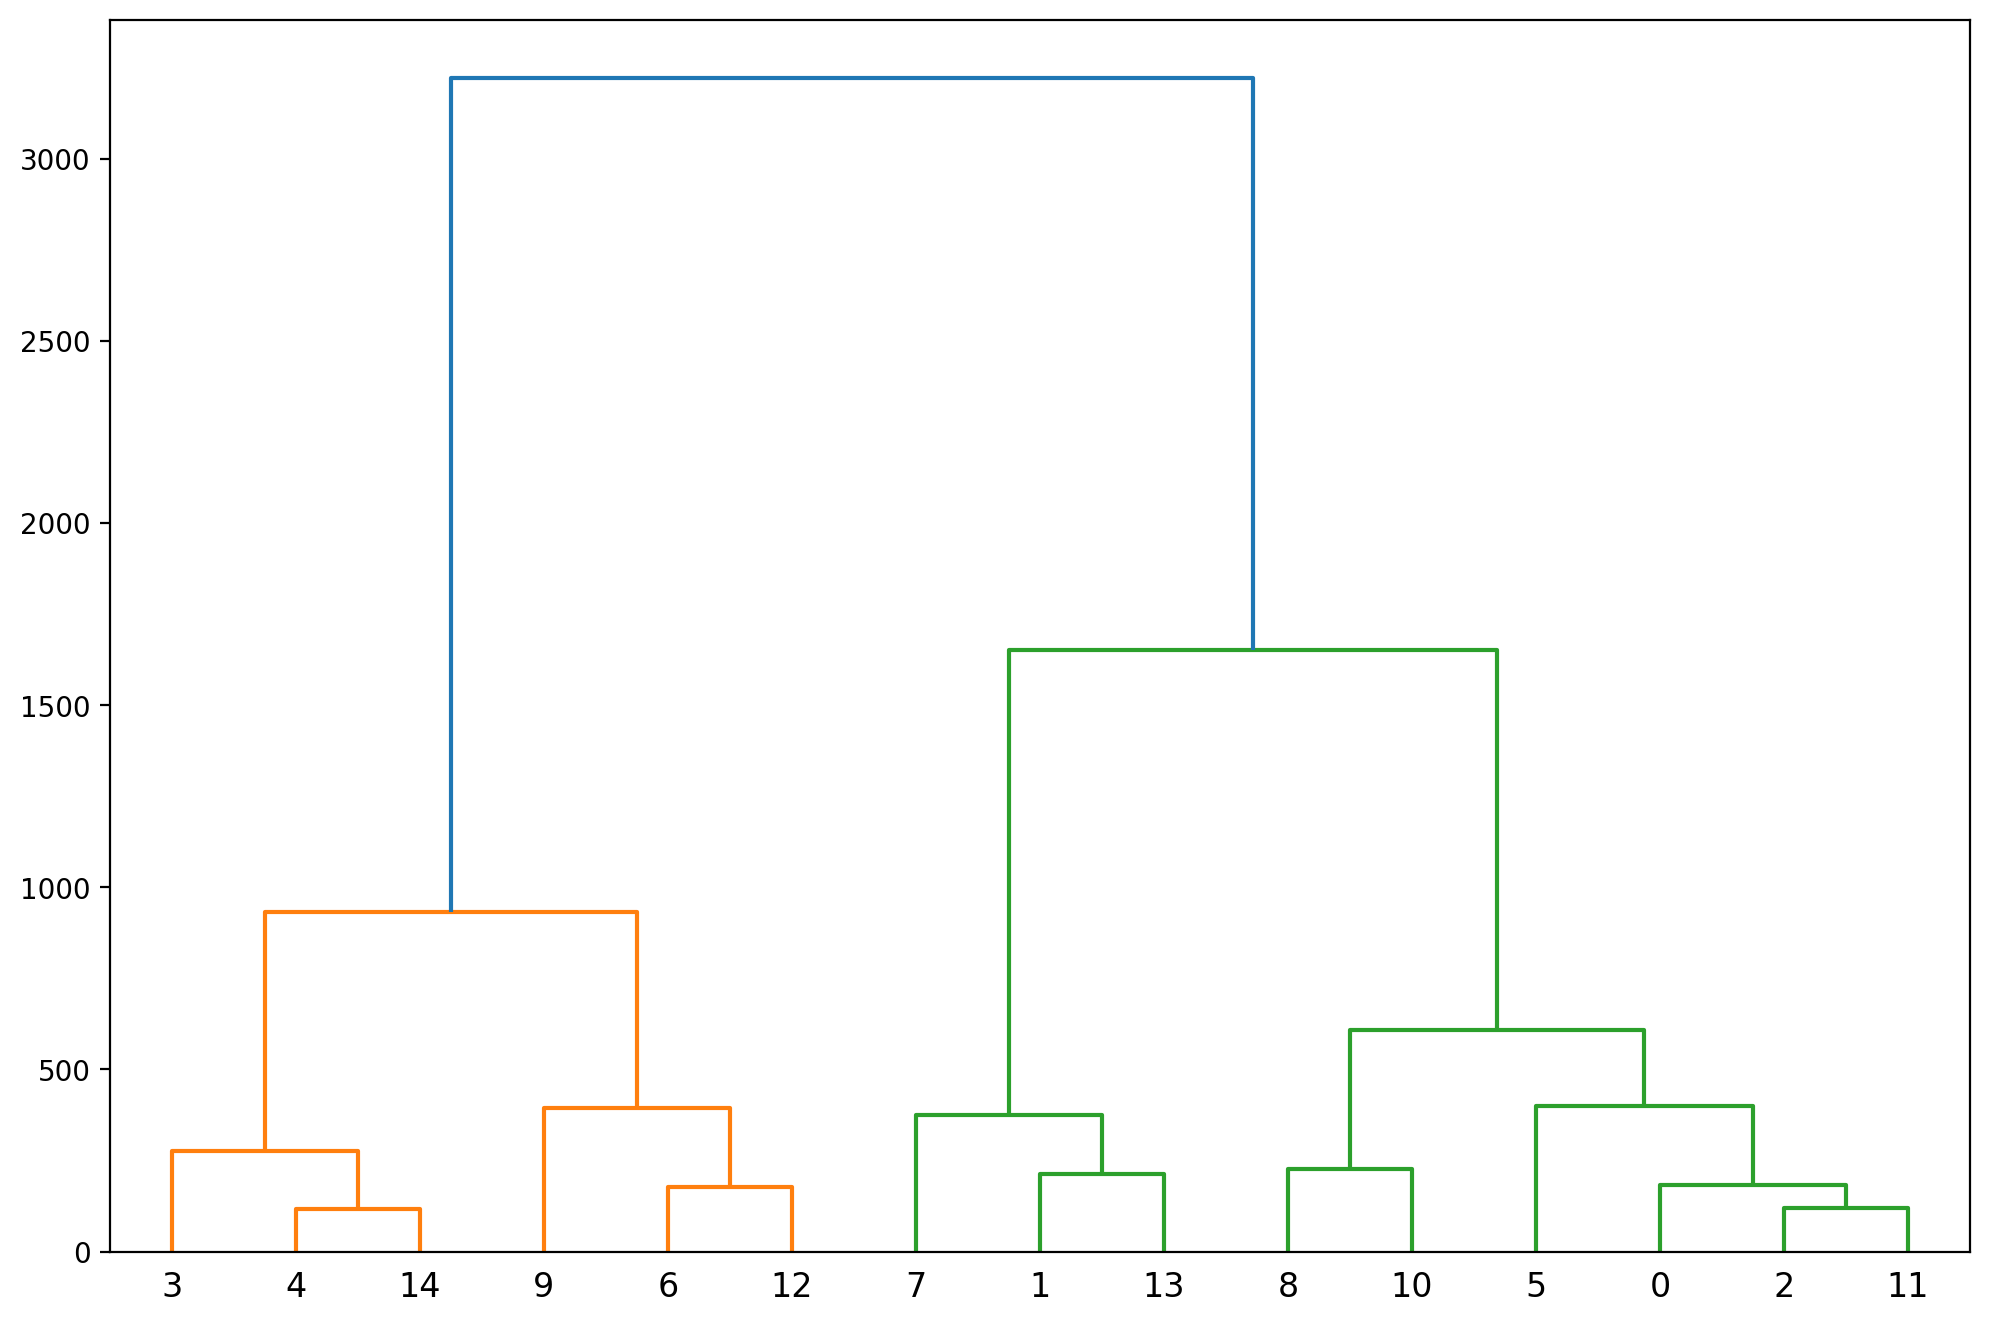

In [17]:
# Agregación de Ward
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 200)
dendrogram(ward_res, ax = ax) #Aquí se escoge la agregación, distancia entre grupos.
plt.show()

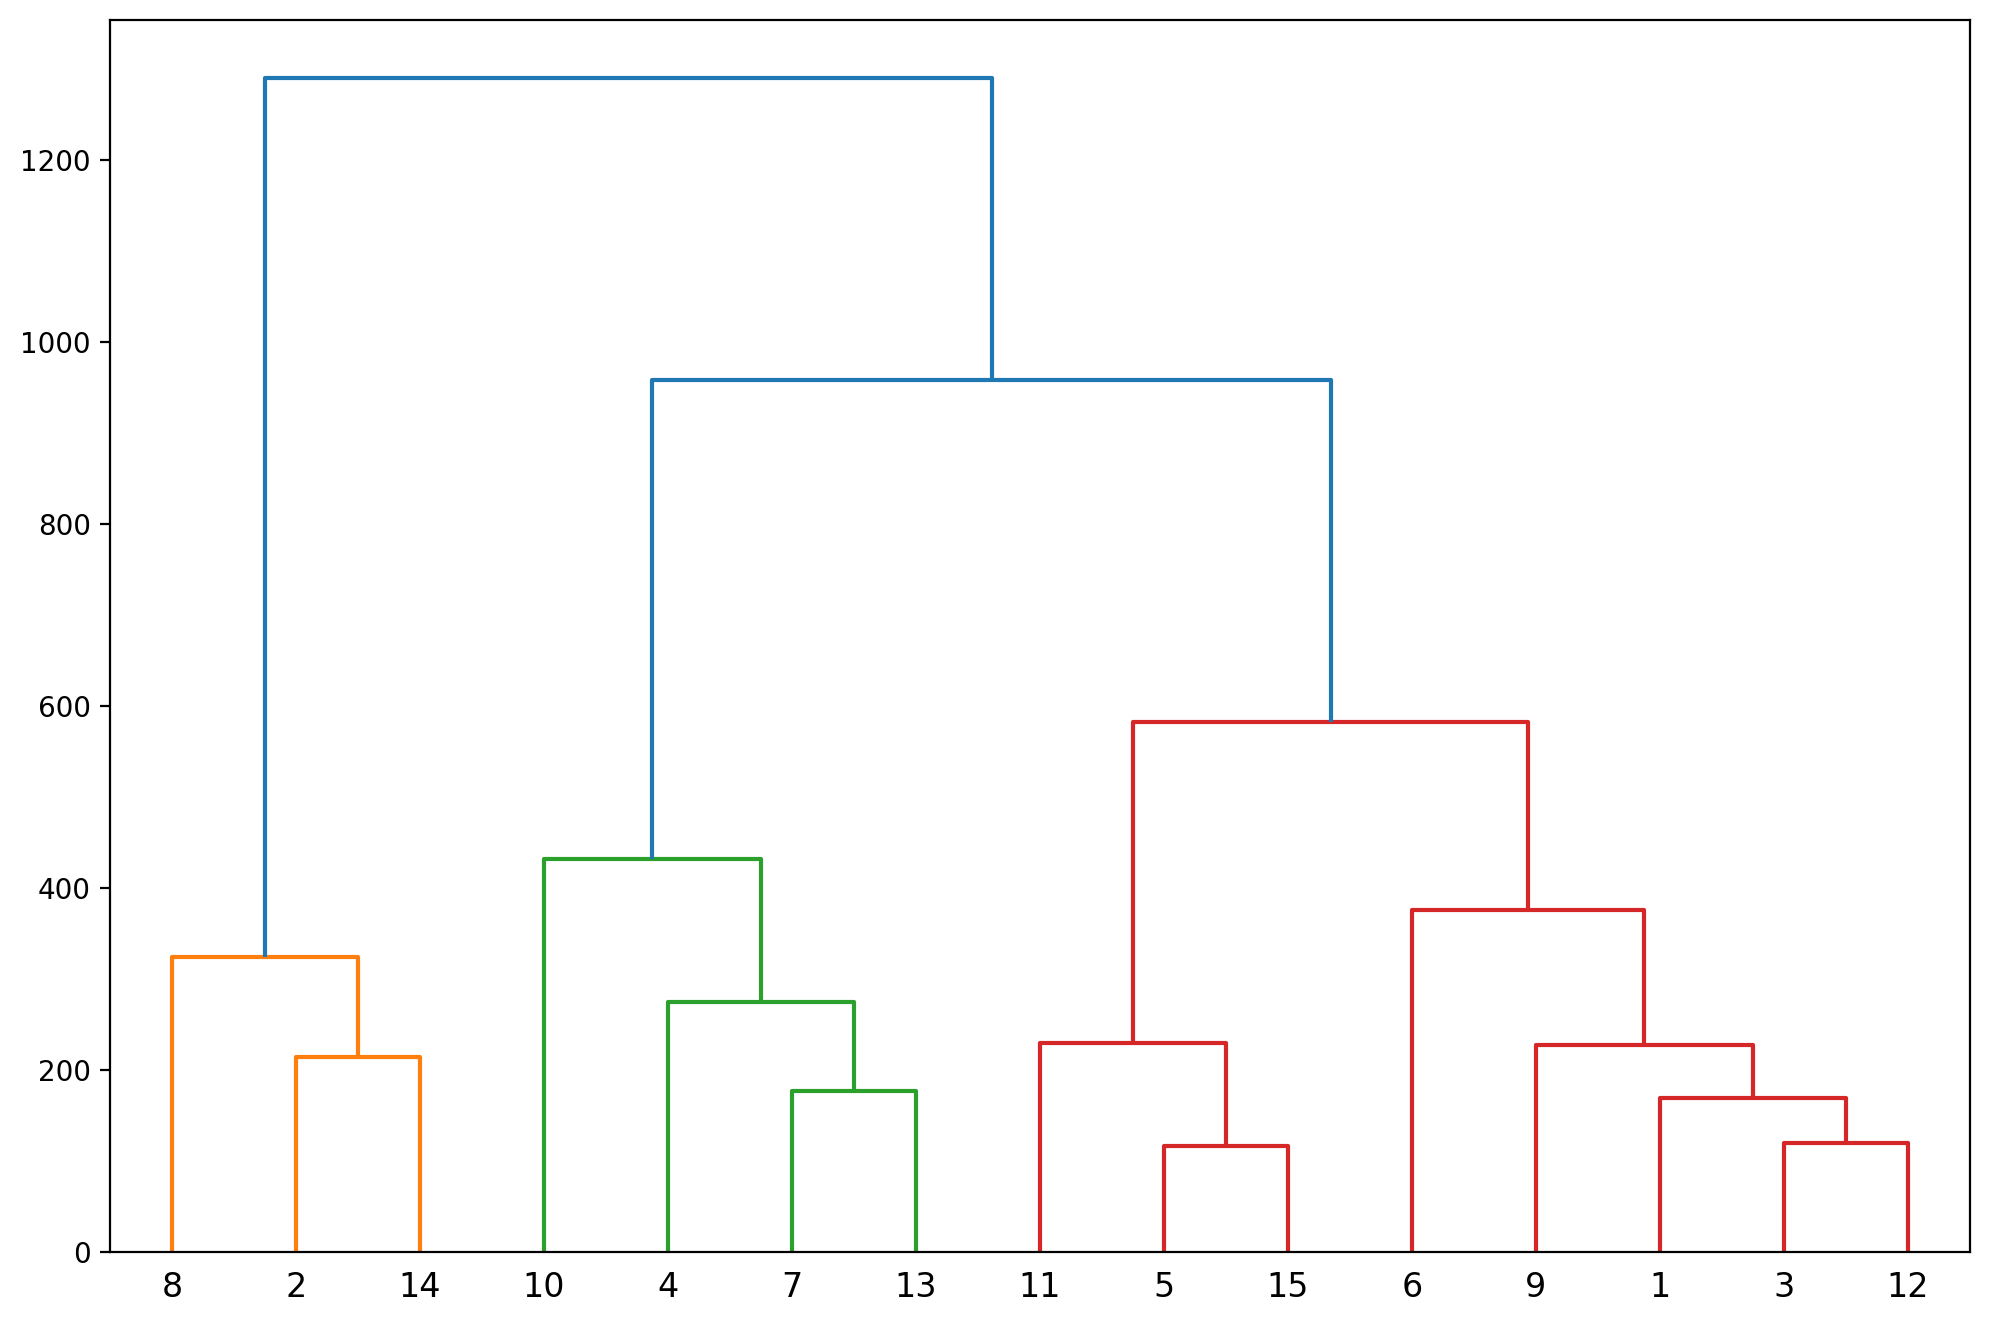

In [18]:
# Salto promedio
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 200)
dendrogram(average_res,labels = df_numerico.index.tolist(), ax = ax) #Aquí se escoge la agregación, distancia entre grupos.
plt.show()

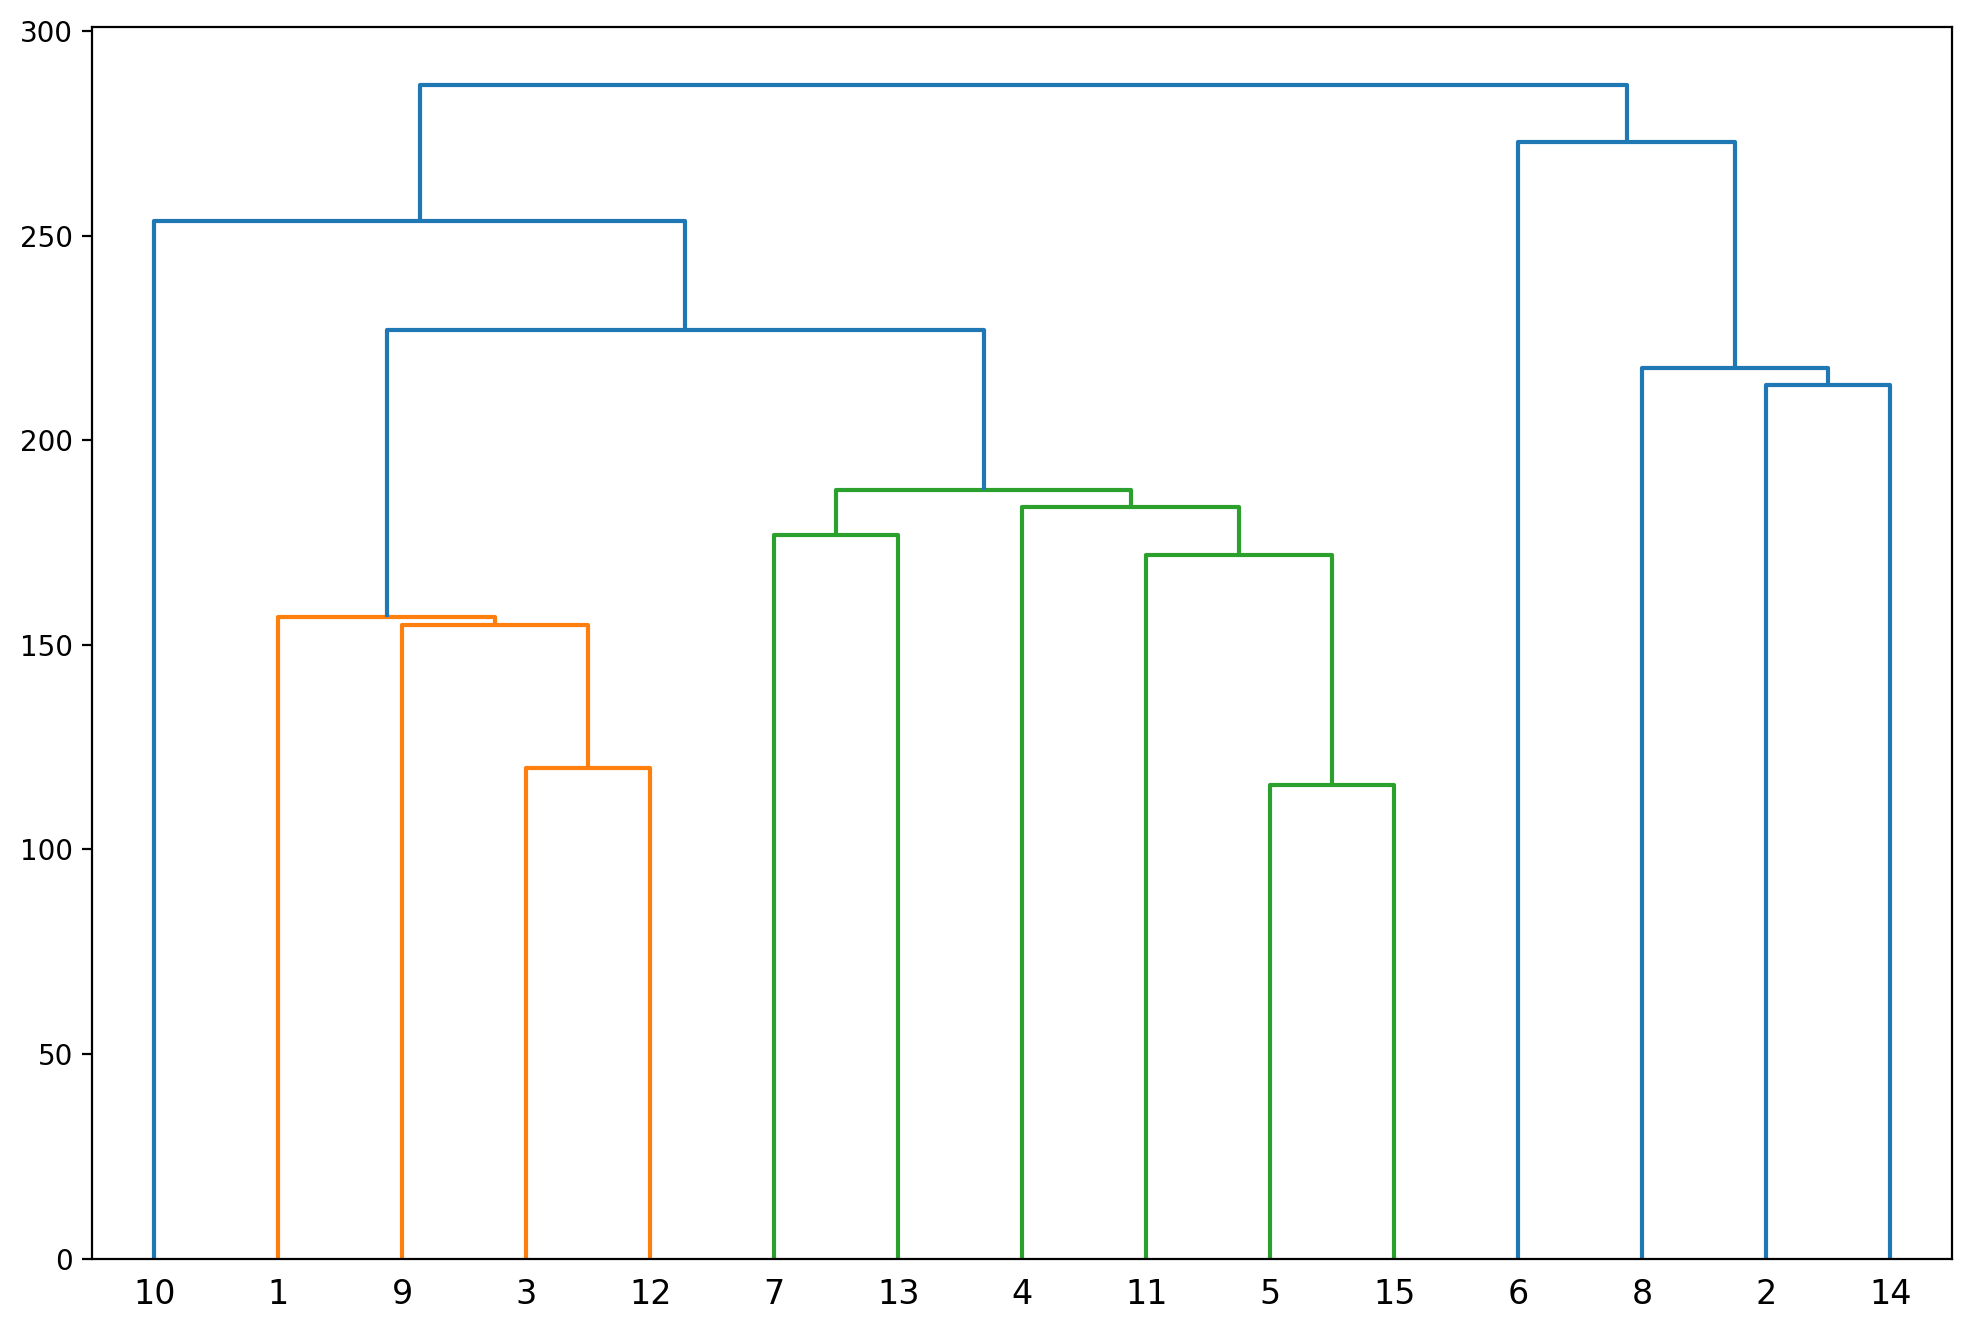

In [19]:
# Salto mínimo
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 200)
dendrogram(single_res,labels = df_numerico.index.tolist(), ax = ax) #Aquí se escoge la agregación, distancia entre grupos.
plt.show()

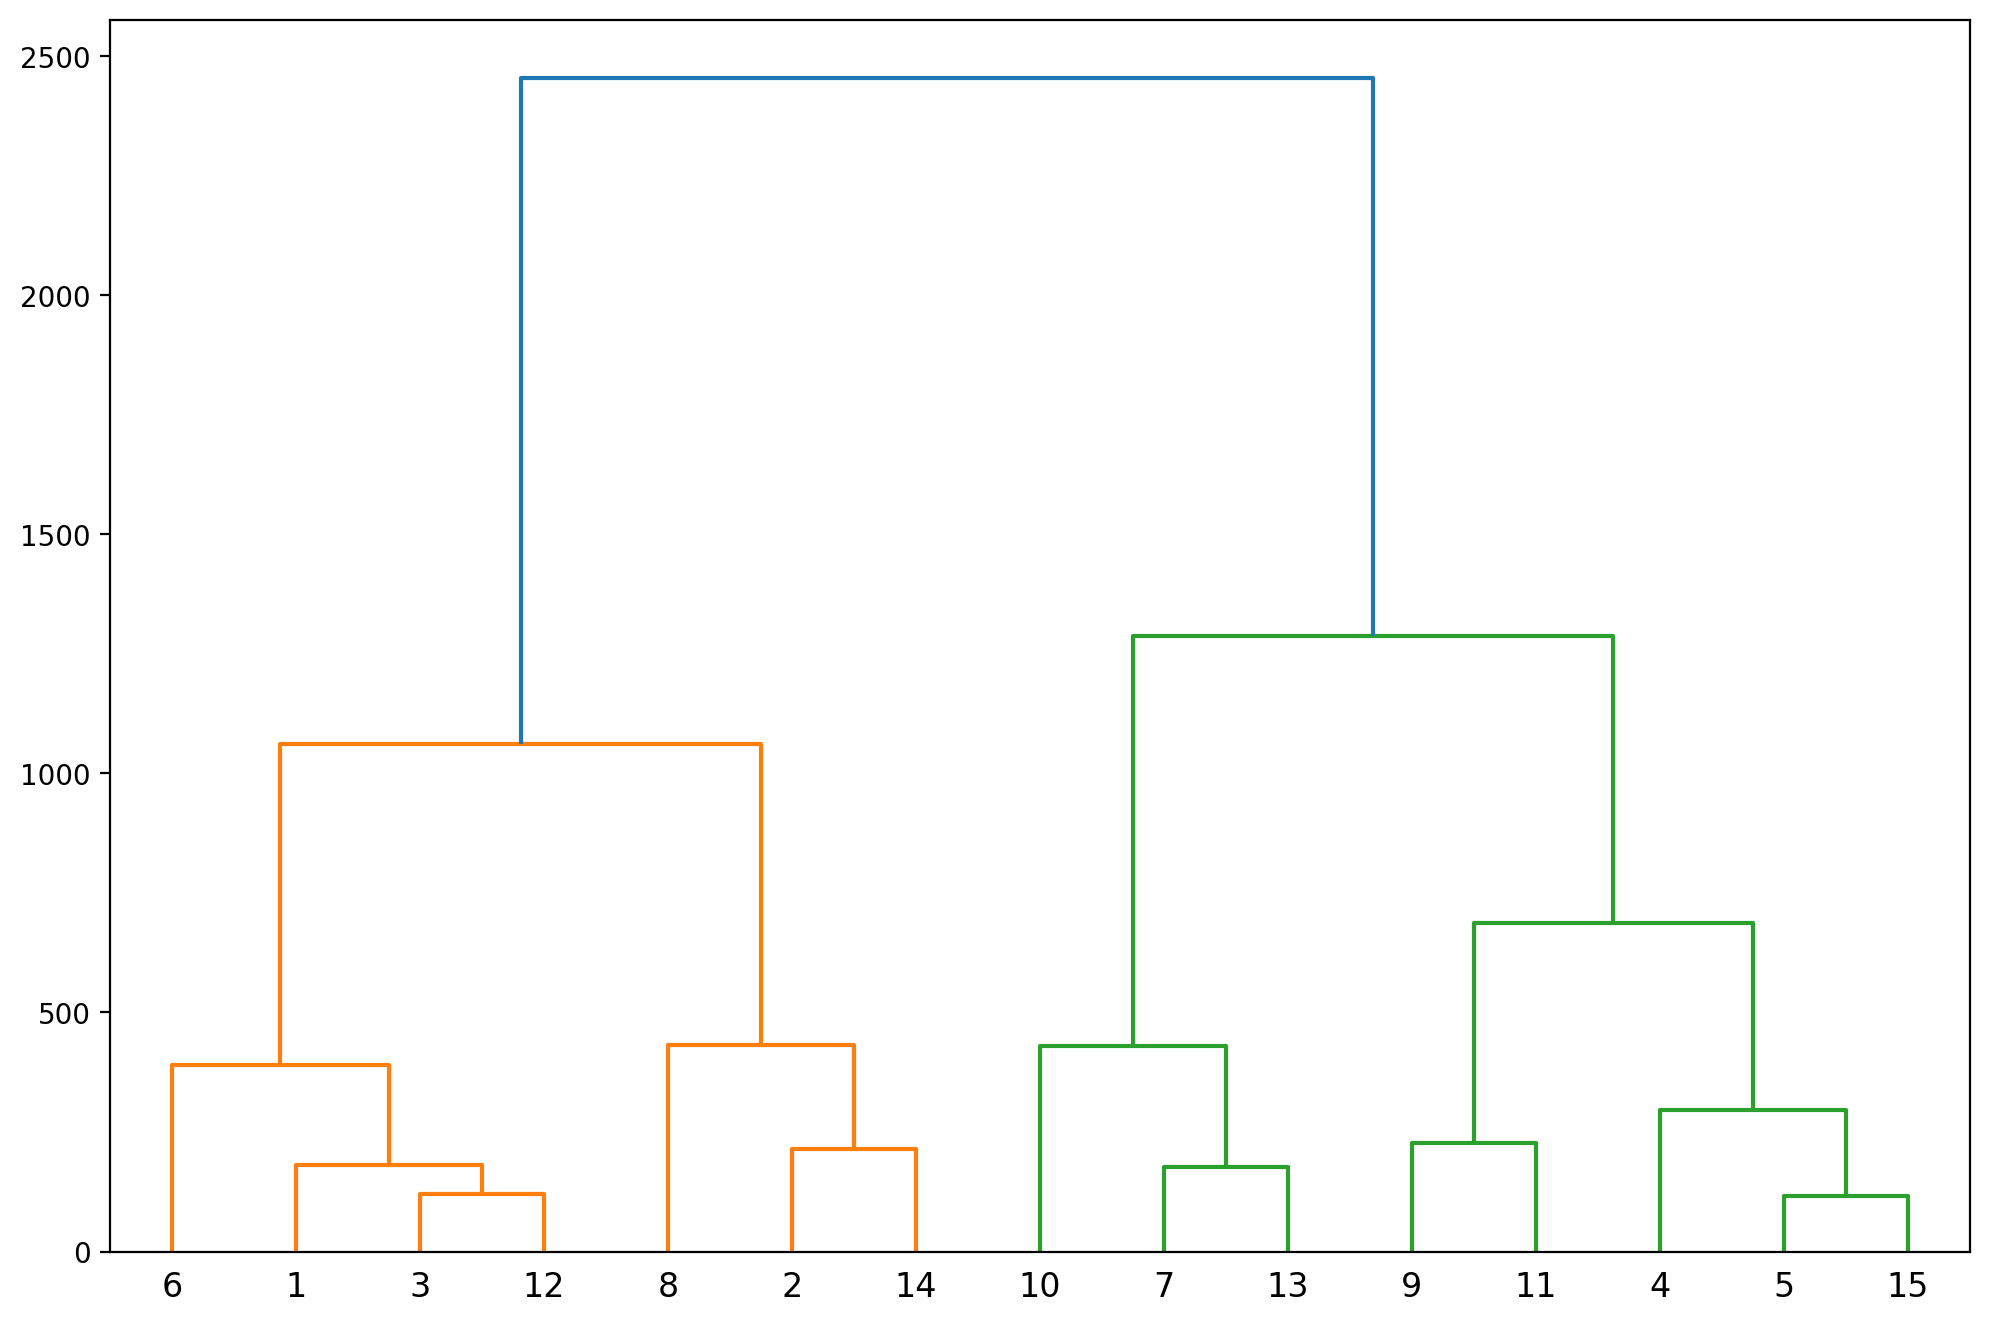

In [20]:
# Salto máximo
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 200)
dendrogram(complete_res,labels = df_numerico.index.tolist(), ax = ax) #Aquí se escoge la agregación, distancia entre grupos.
plt.show()

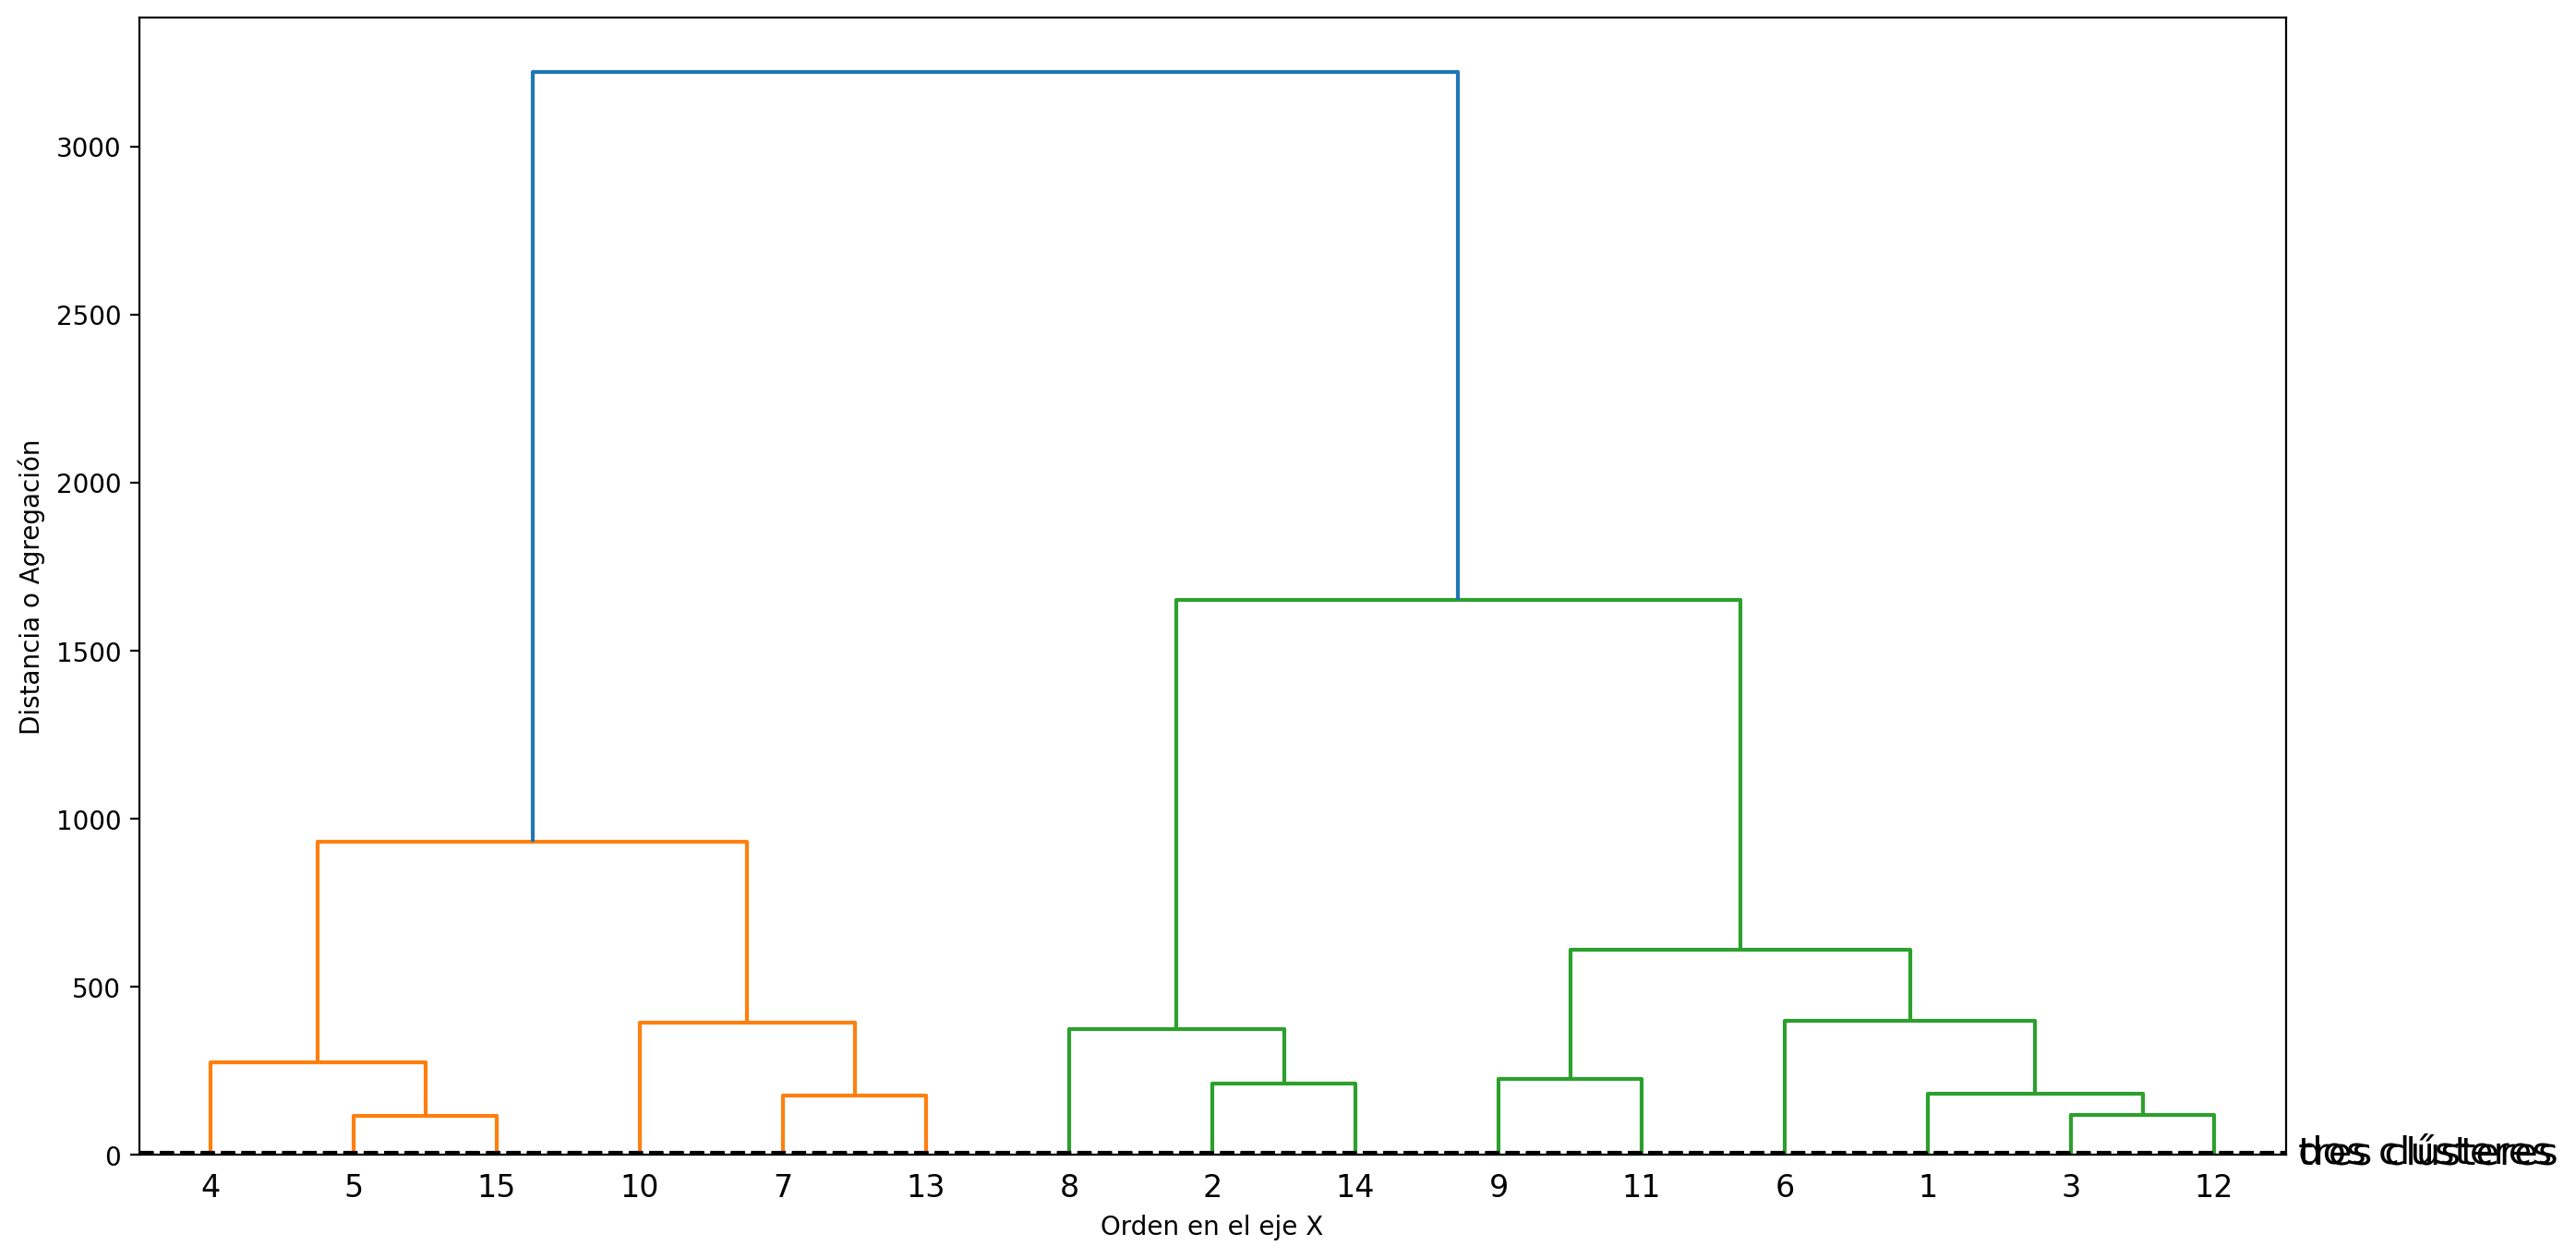

In [21]:
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 200)
dendrogram(ward_res, labels = df_numerico.index.tolist())

# Agrega cortes con 2 y 3 clústeres con agregación de Ward
limites = ax.get_xbound()
ax.plot(limites, [7.25, 7.25], '--', c='k')
ax.plot(limites, [4, 4], '--', c='k')
ax.text(limites[1], 7.25, ' dos clústeres', va = 'center', fontdict={'size': 15})
ax.text(limites[1], 4, ' tres clústeres',   va = 'center', fontdict={'size': 15})
ax.set_xlabel("Orden en el eje X")
ax.set_ylabel("Distancia o Agregación")
plt.show()

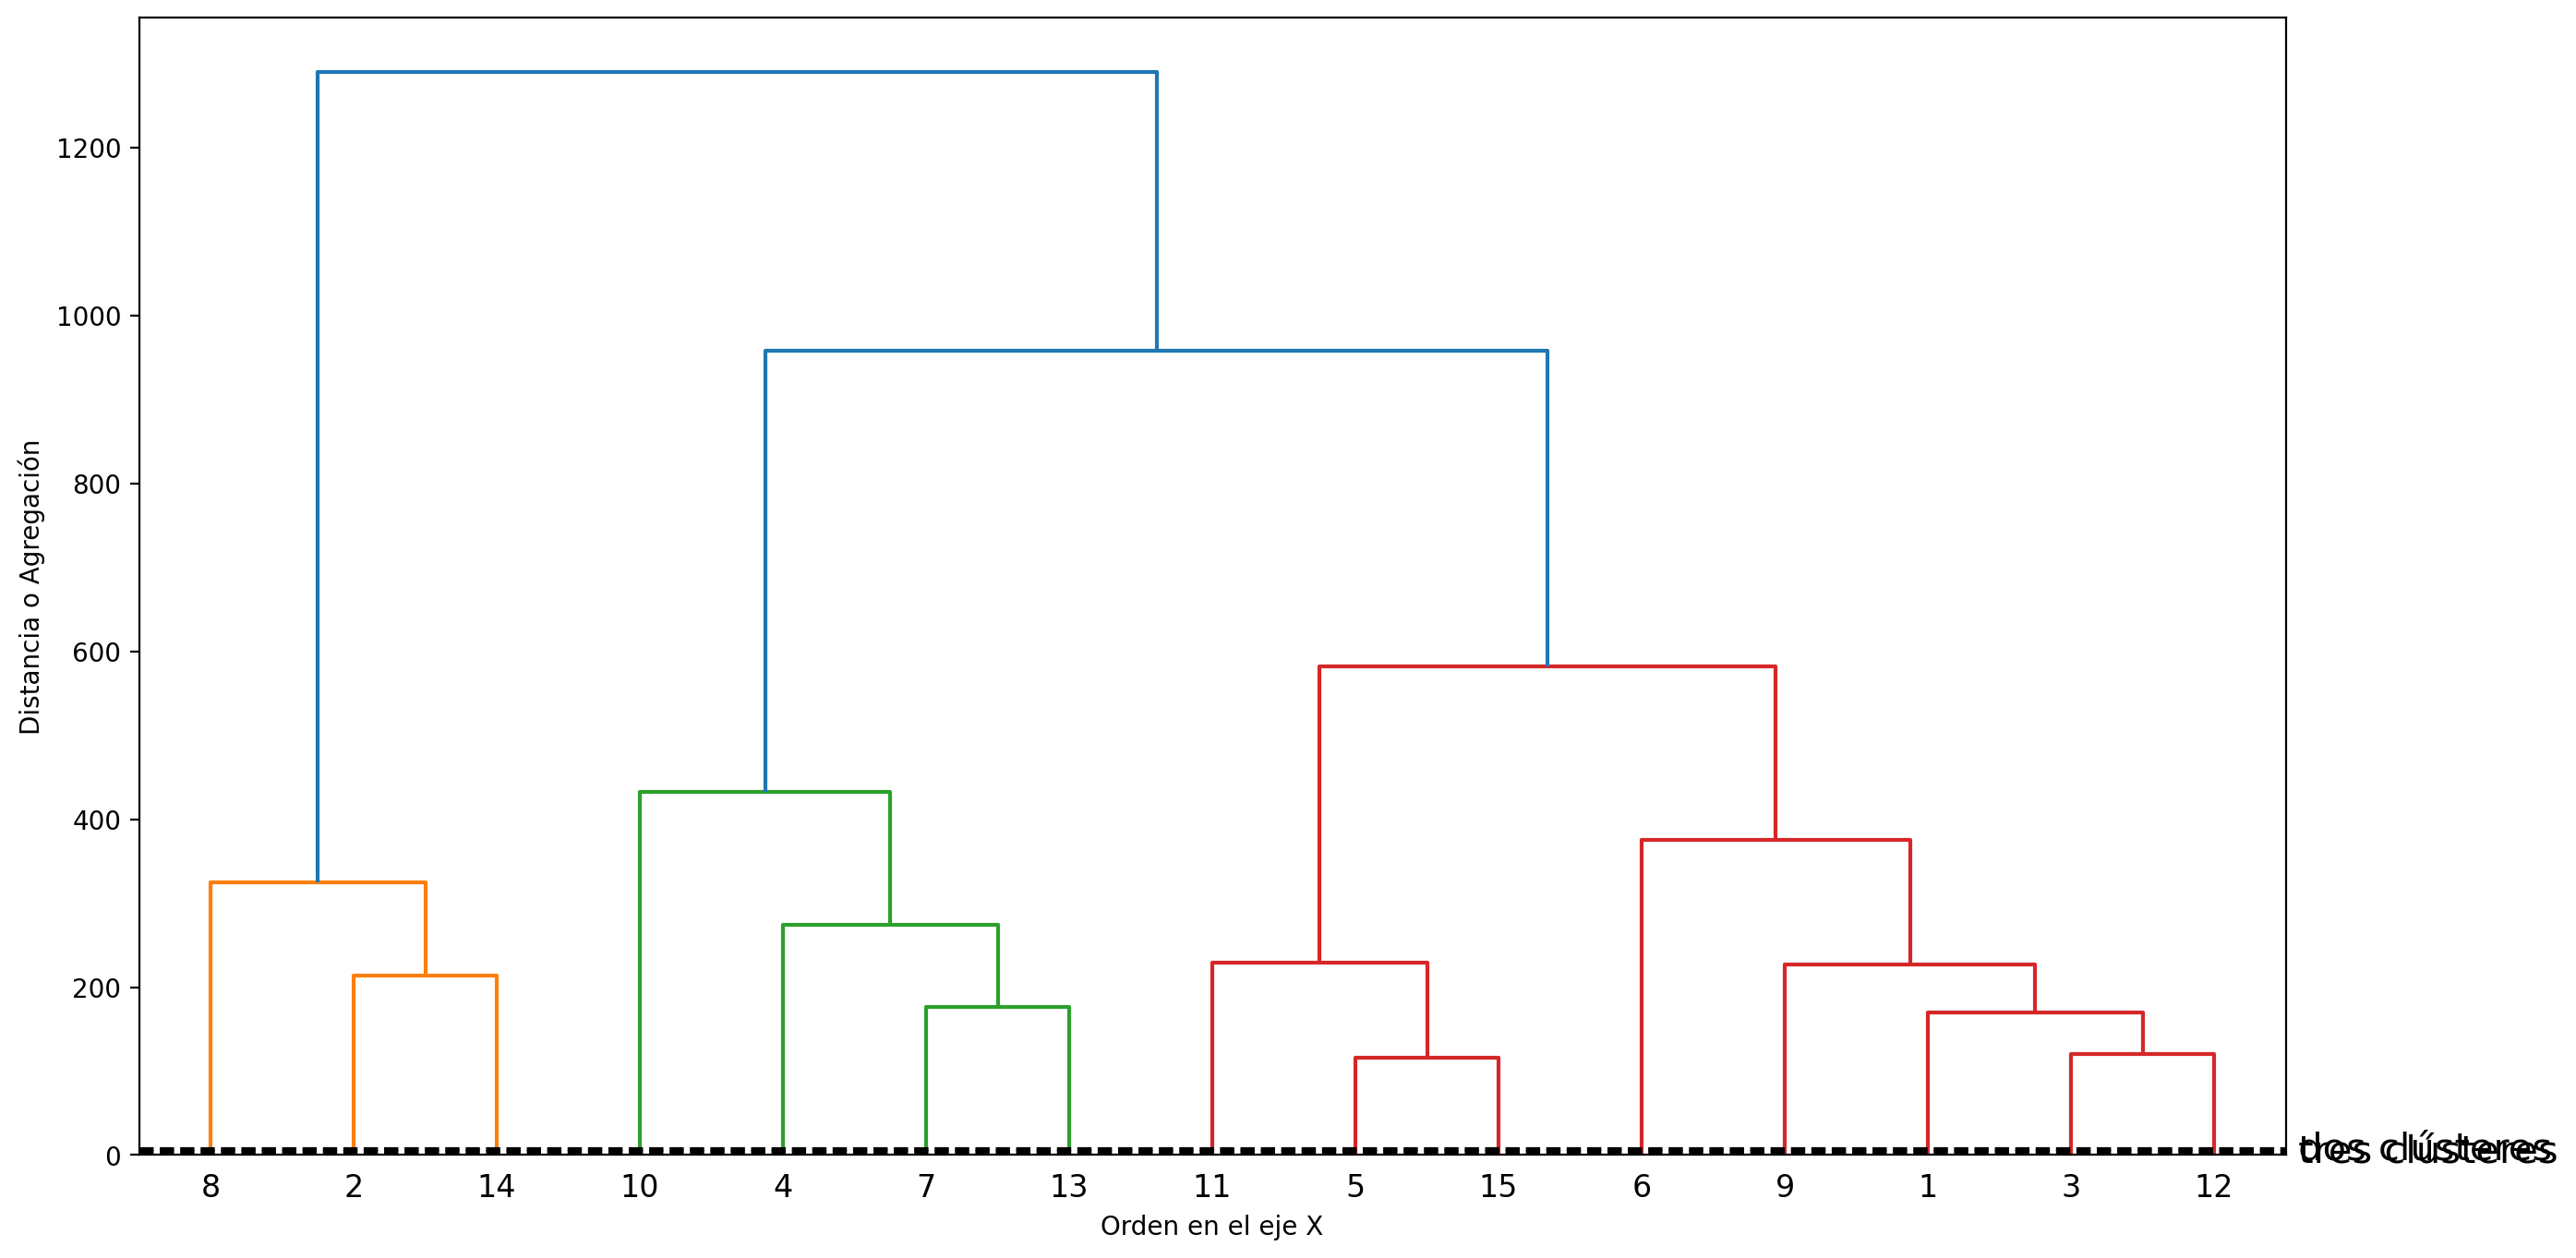

In [22]:
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 200)
dendrogram(average_res, labels = df_numerico.index.tolist())

# Agrega cortes con 2 y 3 clústeres con agregación de average
limites = ax.get_xbound()
ax.plot(limites, [7.25, 7.25], '--', c='k')
ax.plot(limites, [4, 4], '--', c='k')
ax.text(limites[1], 7.25, ' dos clústeres', va = 'center', fontdict={'size': 15})
ax.text(limites[1], 4, ' tres clústeres',   va = 'center', fontdict={'size': 15})
ax.set_xlabel("Orden en el eje X")
ax.set_ylabel("Distancia o Agregación")
plt.show()

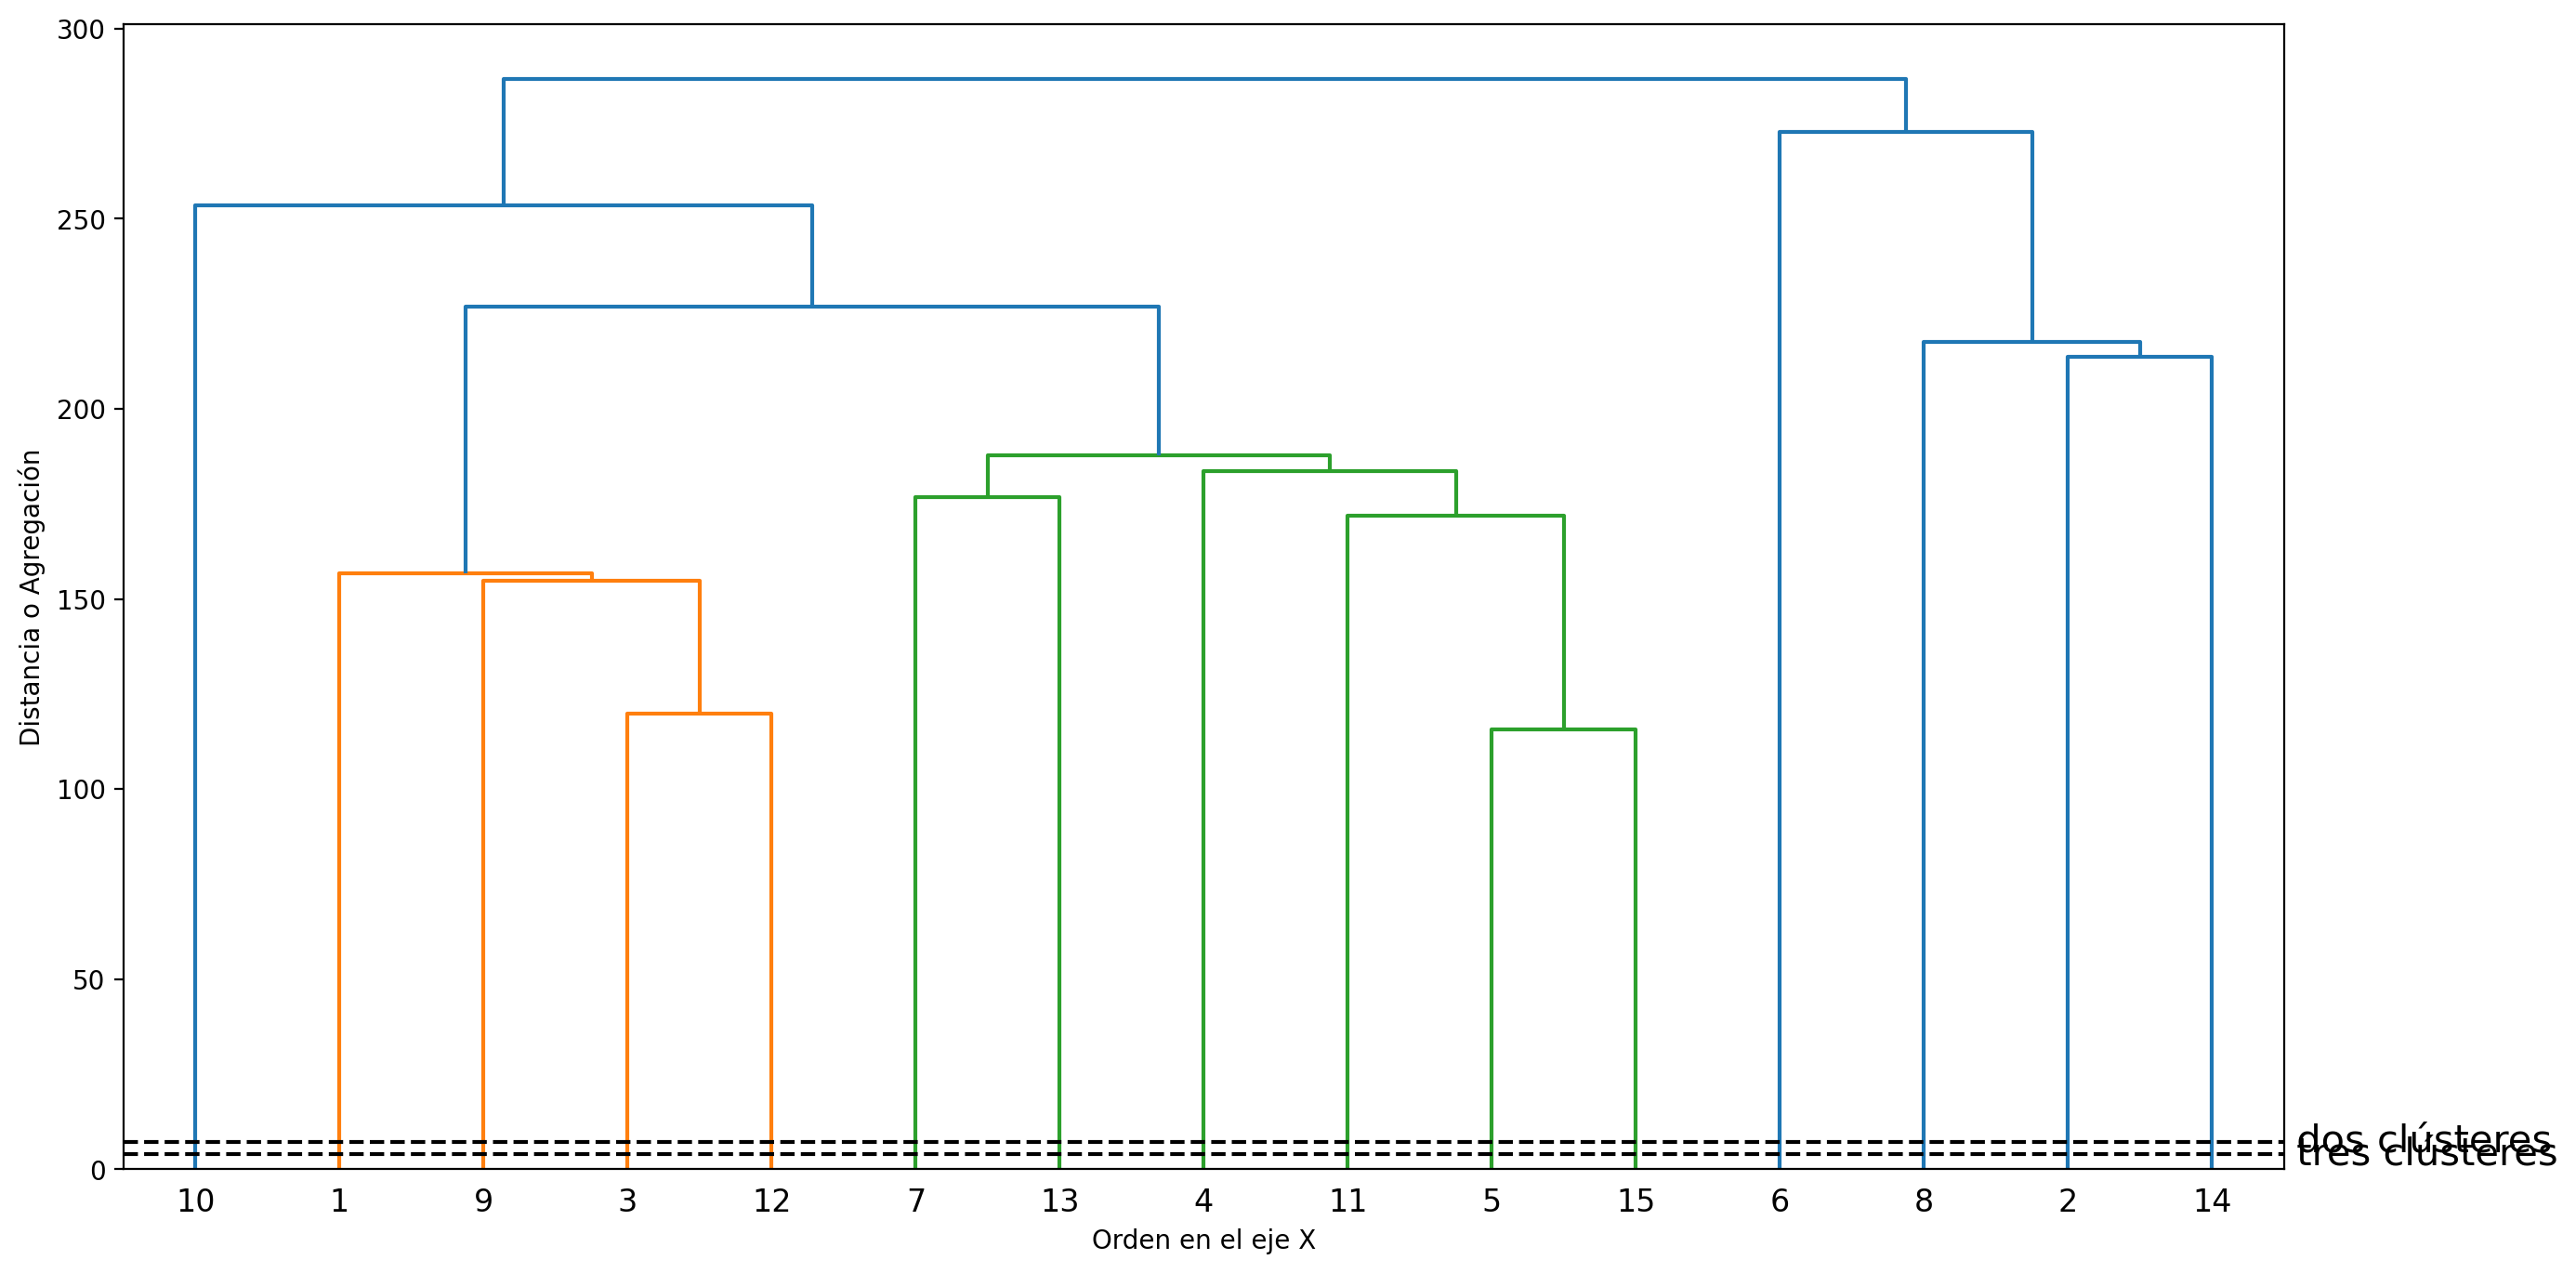

In [23]:
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 200)
dendrogram(single_res, labels = df_numerico.index.tolist())

# Agrega cortes con 2 y 3 clústeres con agregación single
limites = ax.get_xbound()
ax.plot(limites, [7.25, 7.25], '--', c='k')
ax.plot(limites, [4, 4], '--', c='k')
ax.text(limites[1], 7.25, ' dos clústeres', va = 'center', fontdict={'size': 15})
ax.text(limites[1], 4, ' tres clústeres',   va = 'center', fontdict={'size': 15})
ax.set_xlabel("Orden en el eje X")
ax.set_ylabel("Distancia o Agregación")
plt.show()

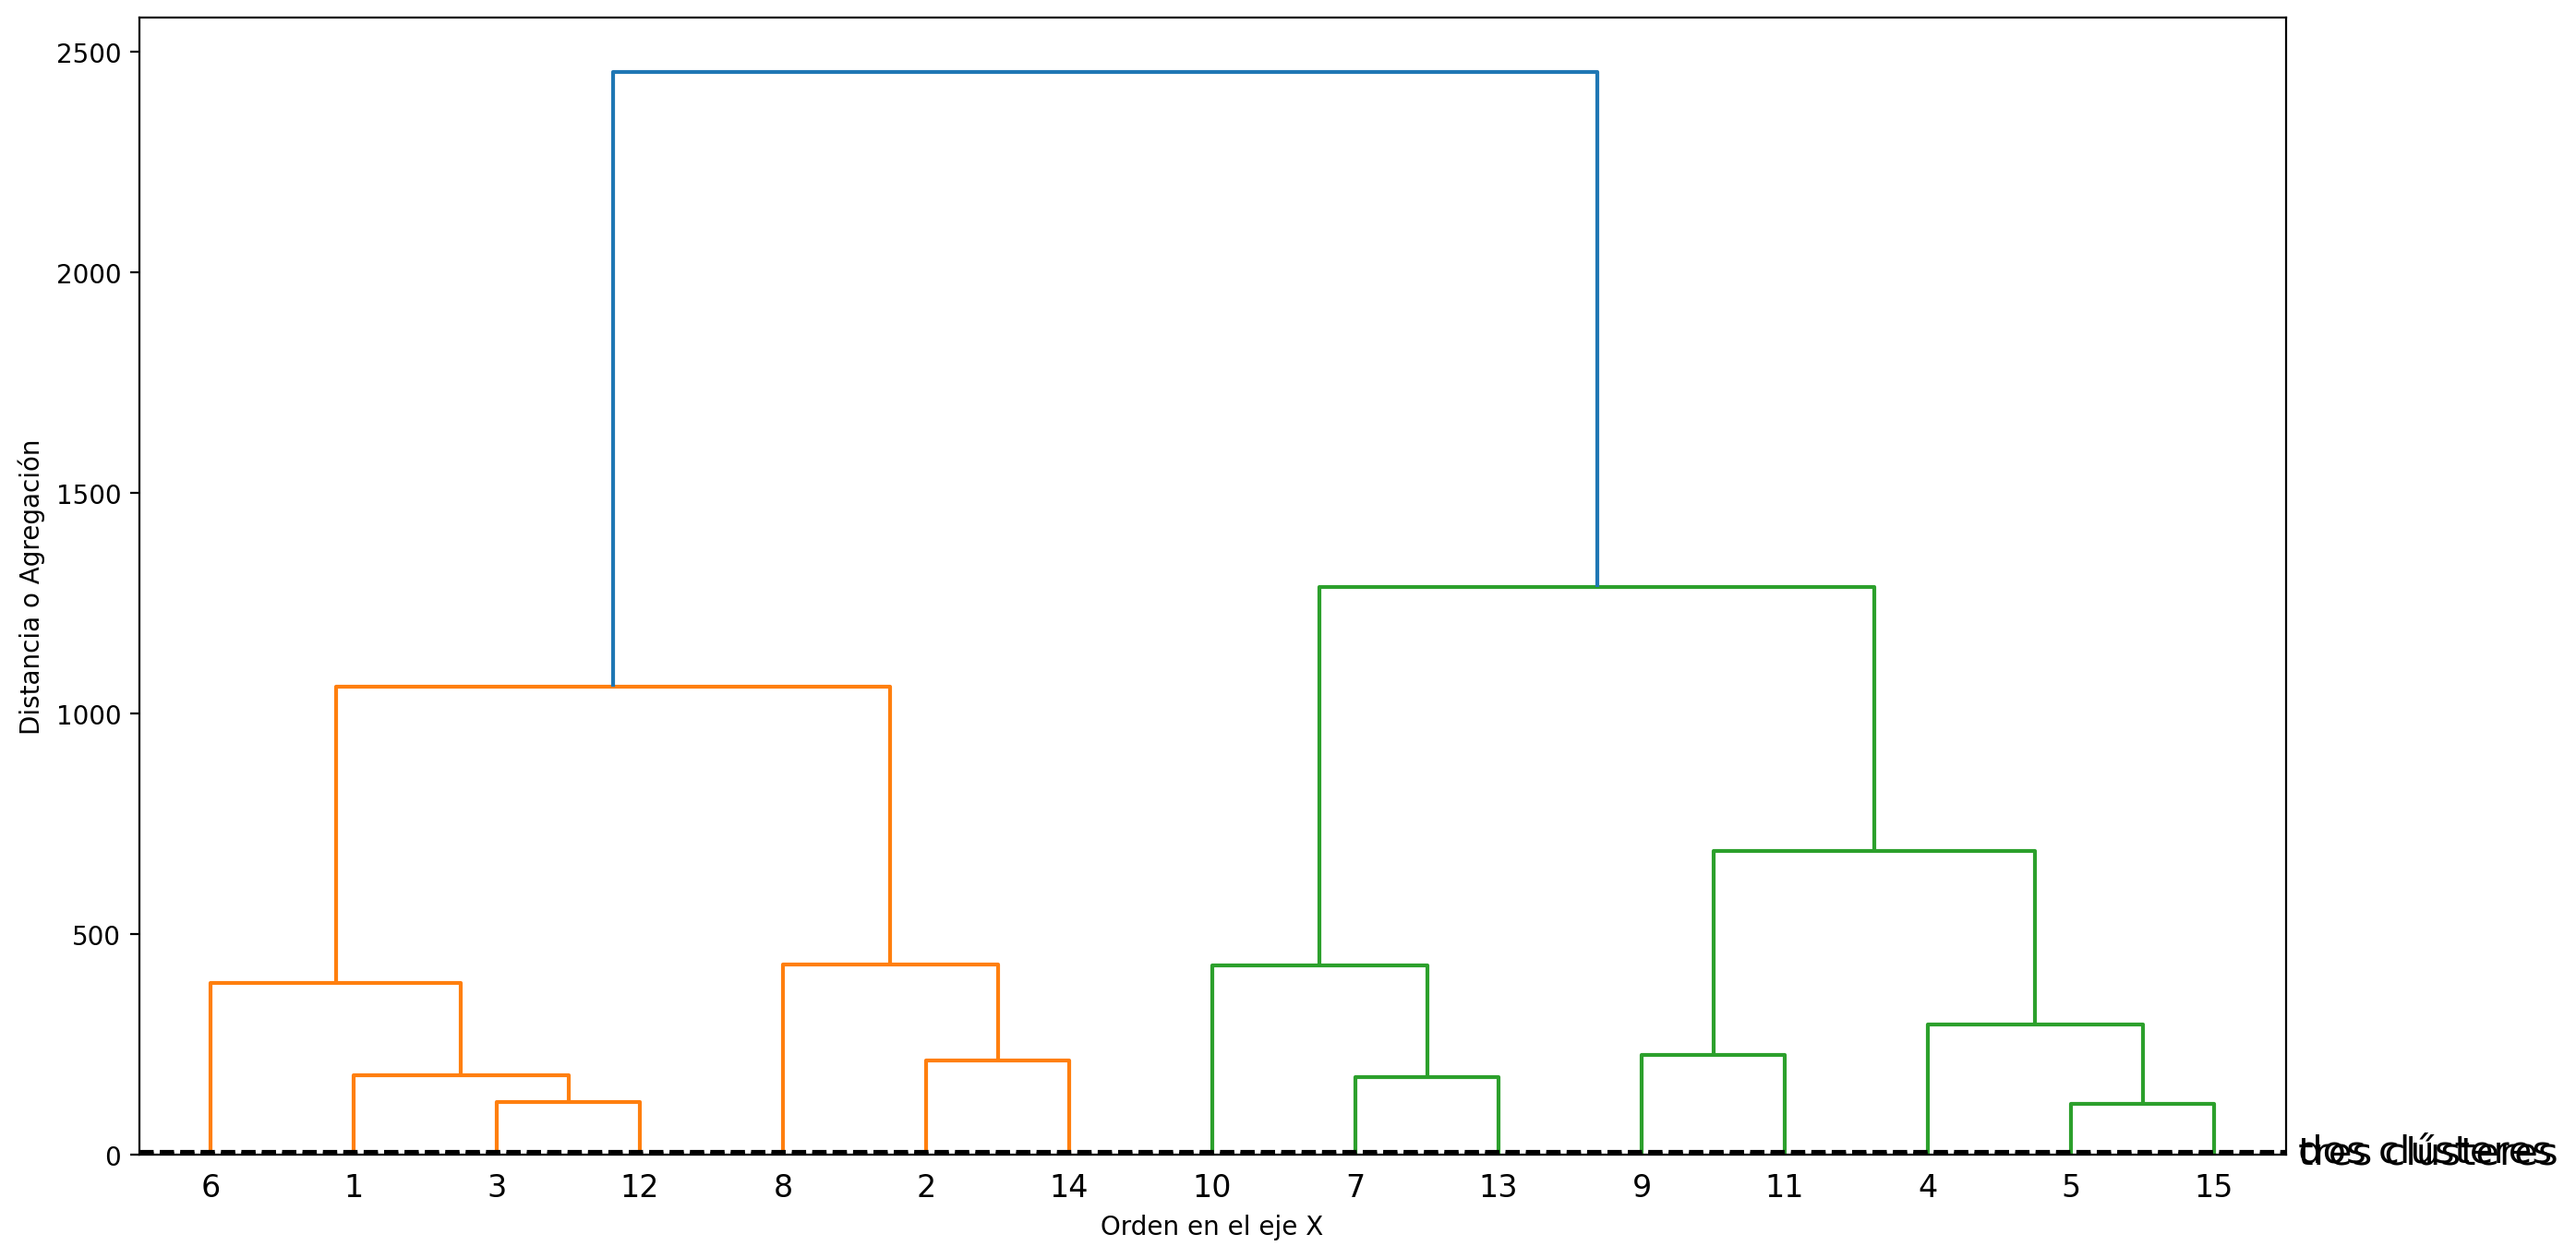

In [24]:
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 200)
dendrogram(complete_res, labels = df_numerico.index.tolist())

# Agrega cortes con 2 y 3 clústeres con agregación complete
limites = ax.get_xbound()
ax.plot(limites, [7.25, 7.25], '--', c='k')
ax.plot(limites, [4, 4], '--', c='k')
ax.text(limites[1], 7.25, ' dos clústeres', va = 'center', fontdict={'size': 15})
ax.text(limites[1], 4, ' tres clústeres',   va = 'center', fontdict={'size': 15})
ax.set_xlabel("Orden en el eje X")
ax.set_ylabel("Distancia o Agregación")
plt.show()

In [25]:
grupos = fcluster(linkage(df_numerico, method = 'ward', metric='euclidean'), 3, criterion = 'maxclust')
grupos = grupos-1 # Se resta 1 para que los clústeres se enumeren de 0 a (K-1), como usualmente lo hace Python
# El siguiente print es para ver en qué cluster quedó cada individuo
grupos

array([2, 1, 2, 0, 0, 2, 0, 1, 2, 0, 2, 2, 0, 1, 0], dtype=int32)

In [26]:
centros = np.array(pd.concat([ns.centroide(0, df_numerico, grupos), 
                              ns.centroide(1, df_numerico, grupos),
                              ns.centroide(2, df_numerico, grupos)]))
centros

array([[  91.66666667,  444.16666667,  115.16666667,    7.13333333,
          66.5       ,  858.33333333, 2012.5       ],
       [ 210.        , 1424.        ,  158.33333333,    8.36666667,
          83.        , 2300.        , 2018.        ],
       [ 155.        ,  908.66666667,  140.33333333,    8.06666667,
          79.        , 1658.33333333, 2016.33333333]])

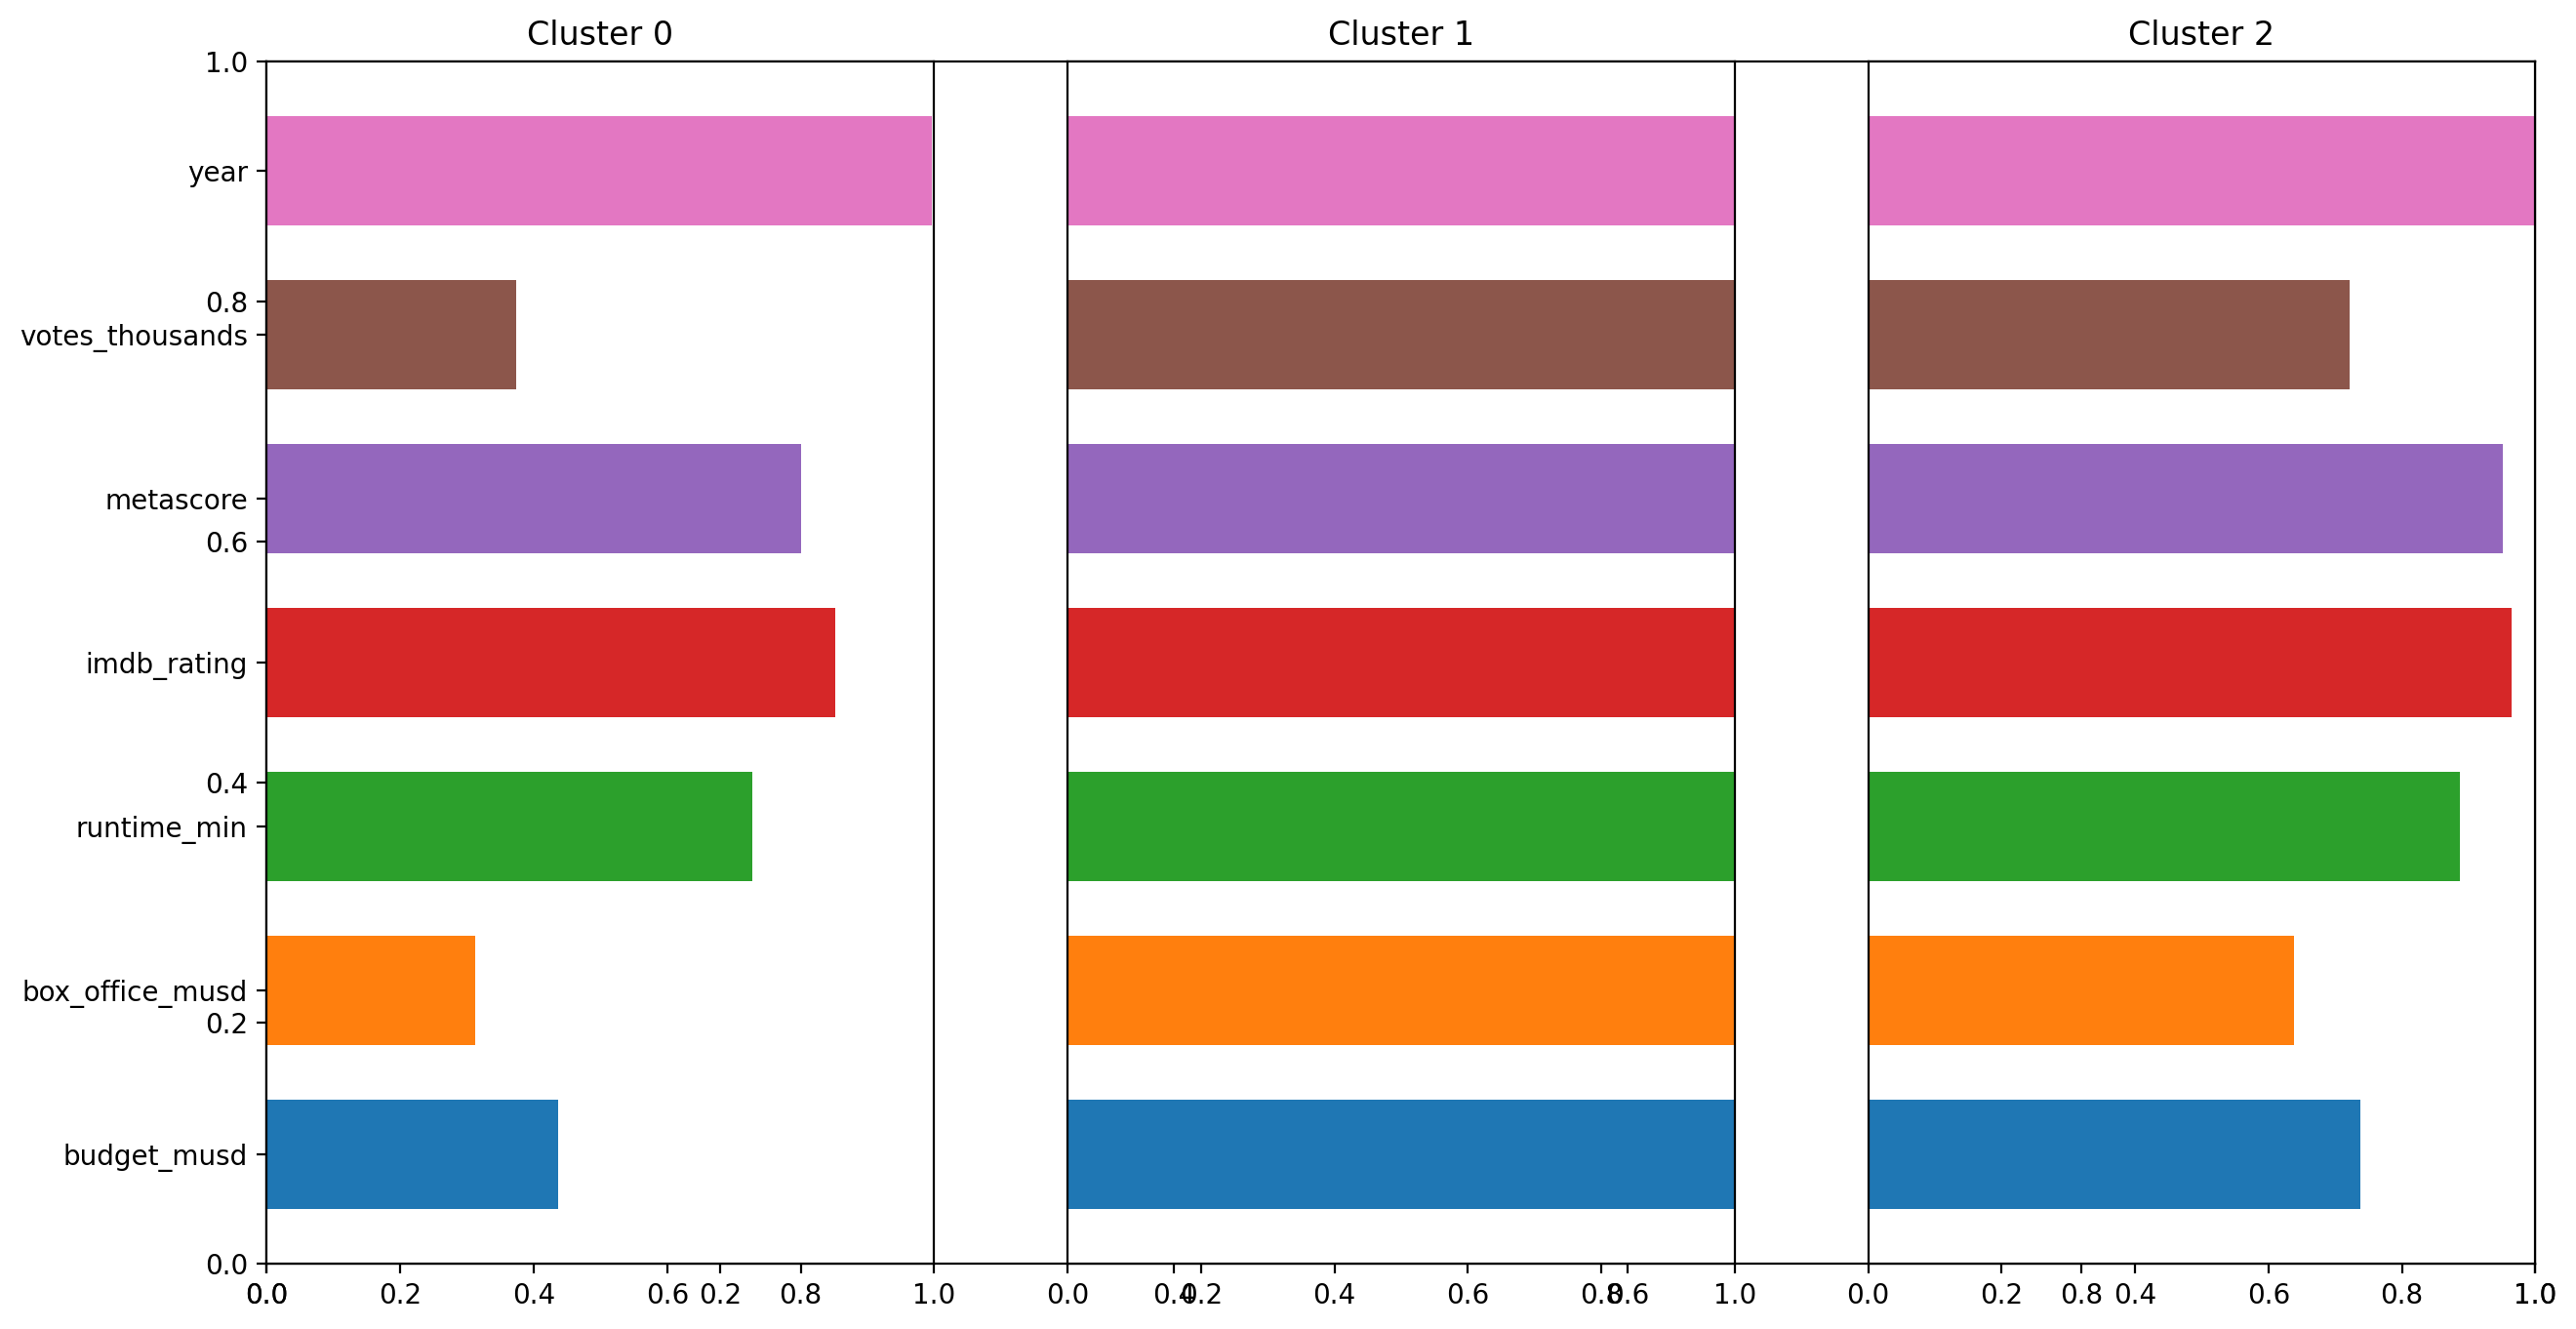

In [27]:
# Grafico de tipo barras
ns.bar_plot(centros, df_numerico.columns, scale=True)
plt.show()

[[  91.66666667  444.16666667  115.16666667    7.13333333   66.5
   858.33333333 2012.5       ]
 [ 210.         1424.          158.33333333    8.36666667   83.
  2300.         2018.        ]
 [ 155.          908.66666667  140.33333333    8.06666667   79.
  1658.33333333 2016.33333333]]


/home/dnunezf/Documents/AI_LABS/Lab_12-03-2026/No_Supervisados.py:59: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize = figsize,dpi = dpi)


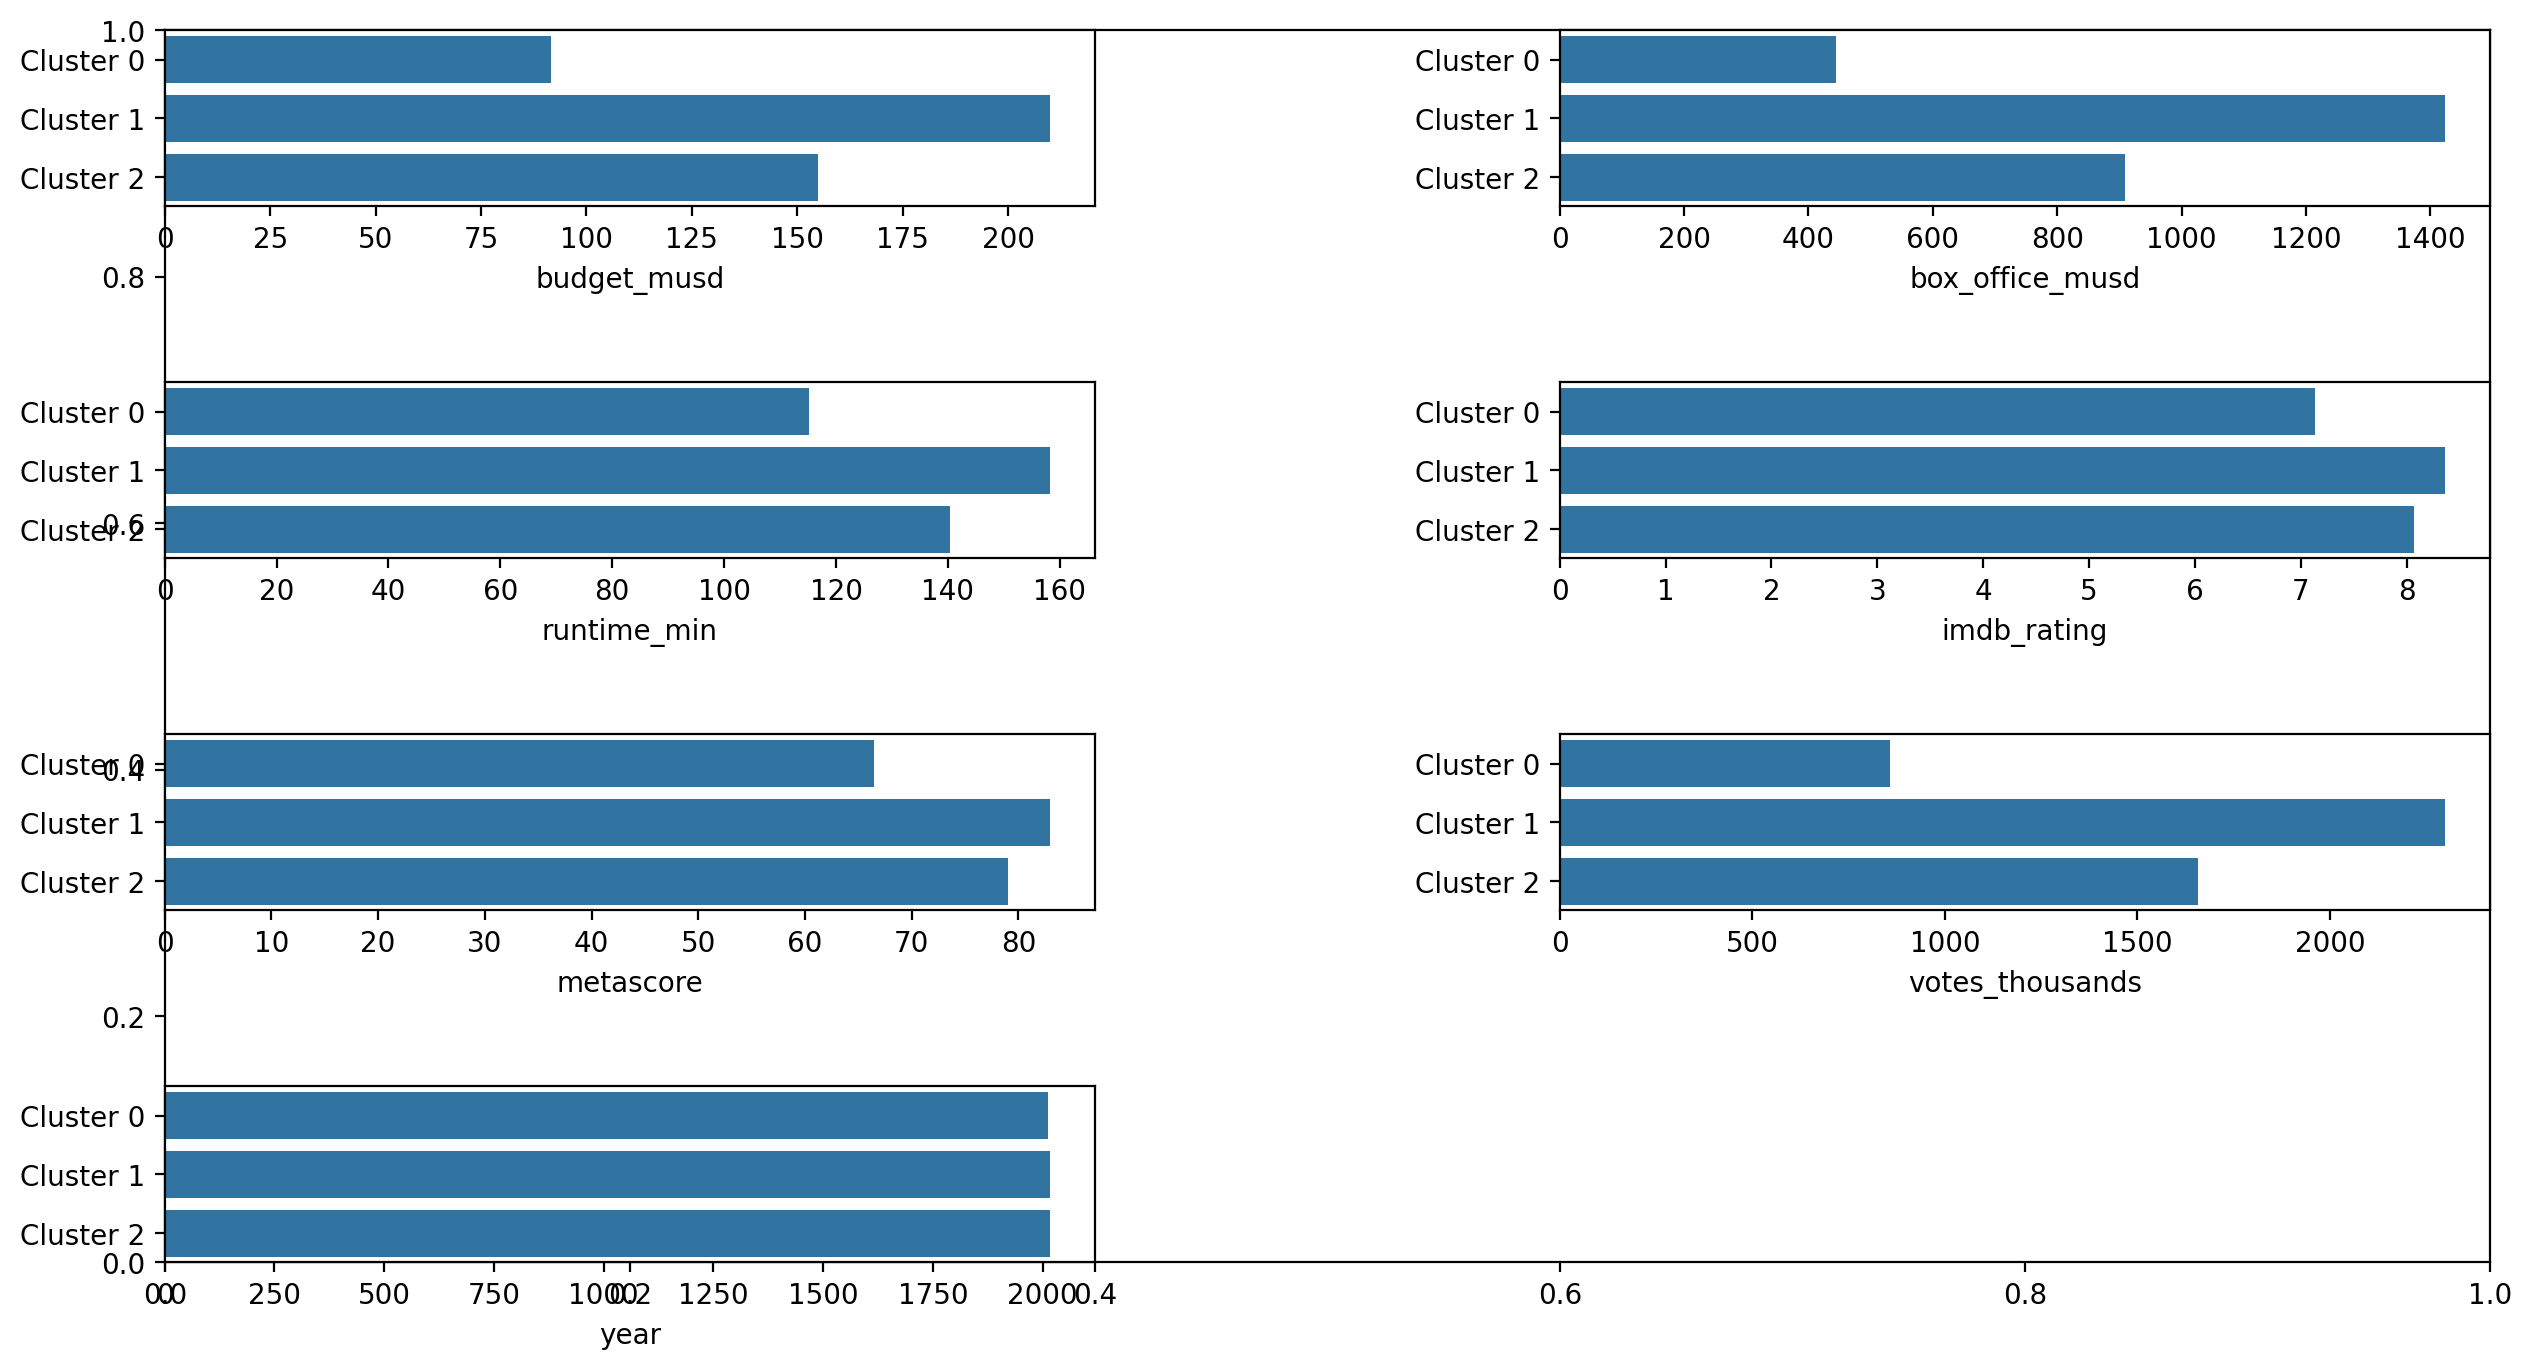

In [28]:
# Gráfico de tipo Barra-Detallado
print(centros)
ns.bar_plot_detail(centros, df_numerico.columns)
plt.show()

In [29]:
# Grafico de tipo Radar
grupos = fcluster(linkage(df_numerico, method = 'ward', metric='euclidean'), 3, criterion = 'maxclust')
grupos = grupos-1 # Se resta 1 para que los clústeres se enumeren de 0 a (K-1), como usualmente lo hace Python
# El siguiente print es para ver en qué cluster quedó cada individuo
grupos

array([2, 1, 2, 0, 0, 2, 0, 1, 2, 0, 2, 2, 0, 1, 0], dtype=int32)

In [30]:
centros = np.array(pd.concat([ns.centroide(0, df_numerico, grupos), 
                              ns.centroide(1, df_numerico, grupos),
                              ns.centroide(2, df_numerico, grupos)]))
centros

array([[  91.66666667,  444.16666667,  115.16666667,    7.13333333,
          66.5       ,  858.33333333, 2012.5       ],
       [ 210.        , 1424.        ,  158.33333333,    8.36666667,
          83.        , 2300.        , 2018.        ],
       [ 155.        ,  908.66666667,  140.33333333,    8.06666667,
          79.        , 1658.33333333, 2016.33333333]])

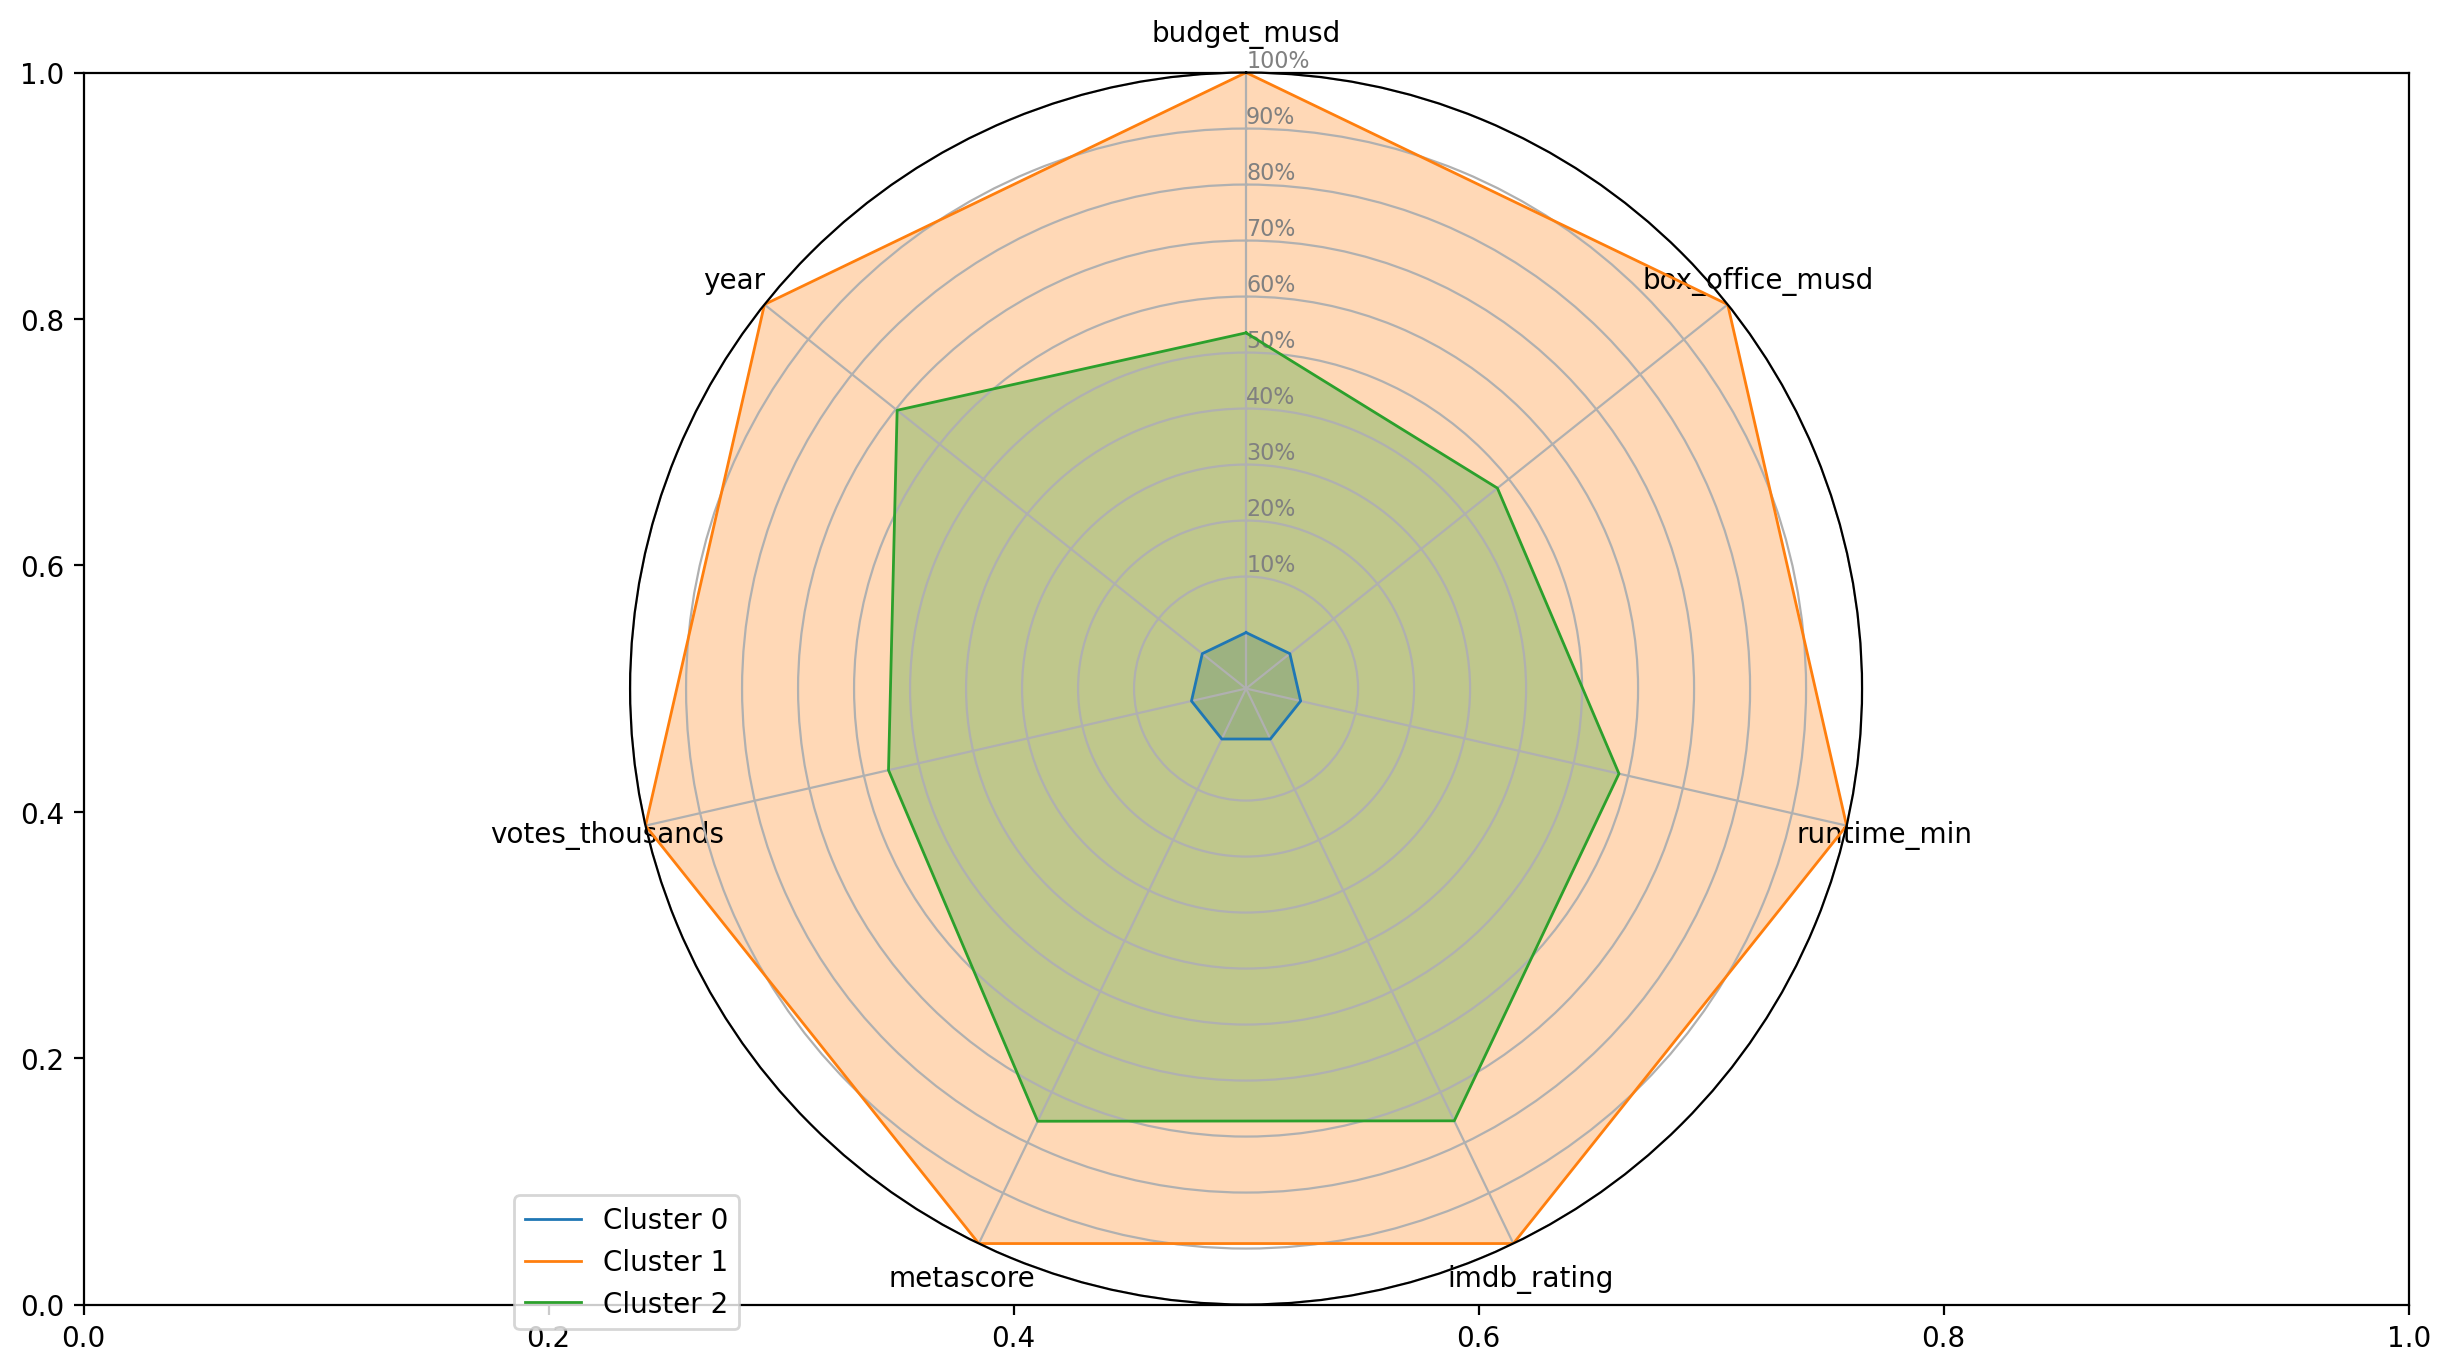

In [31]:
ns.radar_plot(centros, df_numerico.columns)
plt.show()

In [32]:
# Opción d
# se realiza el PCA
df_numerico['grupo']=grupos

In [33]:
df_scaled = pd.DataFrame(StandardScaler().fit_transform(df_numerico),columns=df_numerico.columns,
                                   index = df_numerico.index) #La clase StandardScaler tiene el método fit_transform que estandariza los datos y además lo pasamos a una estructura de dataframe                                  
# Instancia PCA, reduce las dimensiones a 2                              
pca = PCA(n_components = 2)  
#Obtiene los componentes principales
componentes = pca.fit_transform(df_scaled) # El método fit_transform de la instancia PCA genera los cálculos del ACP
df.shape

(15, 7)

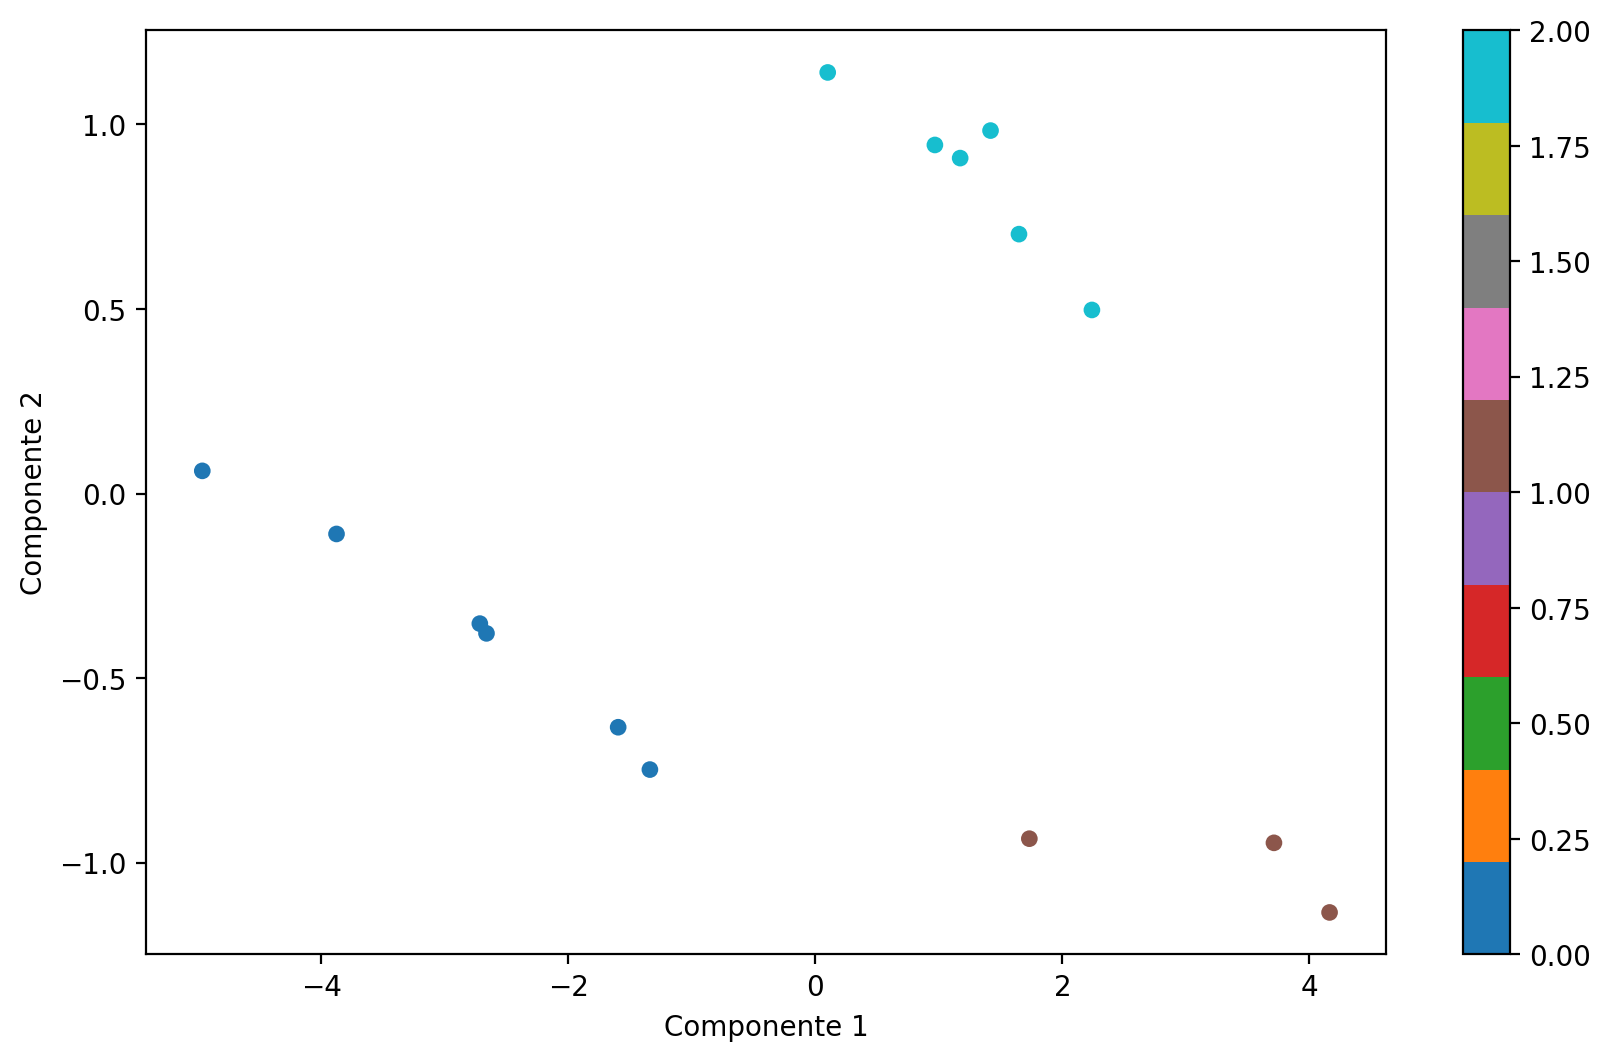

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize = (10,6), dpi = 200)
plt.scatter(componentes[:, 0], componentes[:, 1],
c=df_numerico.grupo, edgecolor='none', alpha=1,
cmap=plt.colormaps.get_cmap('tab10'))
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.colorbar()
plt.show()